# Seasonal Forcing Ensemble Experiment

This notebook now supports two practical workflows for the **seasonal forcing perturbation experiment**:

1. **Analysis-first mode**: load an existing WY2021 baseline and completed ensemble outputs for evaluation and plotting
2. **Full rebuild mode**: optimize, build forcing ensembles, rerun SUMMA, then evaluate
3. **Evaluate** sensitivity via water balance (ET, storage change) and runoff ratio
4. **Visualize** precipitation and streamflow responses with spaghetti plots and summary figures

The default settings below are configured for the completed **East River lumped WY2021** experiment so you can start from analysis without rerunning the expensive steps.

---

## 0. Setup & Imports

In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import yaml
import matplotlib.pyplot as plt

# Add project root to path
PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / 'ess-project' / 'modeling'))

from seasonal_ensemble_experiment import (
    SeasonalEnsembleExperiment,
    ExperimentConfig,
    ParameterOptimizer,
    ModelRunner,
    ForcingEnsembleBuilder,
    EnsembleRunner,
    ParallelEnsembleRunner,
    EnsembleEvaluator,
    EnsembleVisualizer,
    SEASONS,
)

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro


## 1. Configuration

Set up the experiment by pointing to your CONFLUENCE config file and defining the time windows.

In [5]:
# ============================================================
# USER CONFIGURATION — defaults target the completed East River WY2021 run
# ============================================================

# Path to the CONFLUENCE config YAML used for the seasonal experiment
CONFIG_PATH = str(
    PROJECT_ROOT / 'ess-project' / '0_config_files' / 'config_East_River_lumped_seasonal_noxPlicit.yaml'
)

# Long-term baseline period used when rebuilding the experiment
BASELINE_START = '2000-10-01 01:00'
BASELINE_END   = '2020-09-30 23:00'

# Target water year (the year we perturb and analyze)
TARGET_YEAR = 2021

# Donor water years — one replaced season from each of the prior 20 years
DONOR_YEARS = list(range(2001, 2021))

# Default to analysis-only so the notebook can be run safely end-to-end
ANALYSIS_ONLY = True
SKIP_OPTIMIZATION = True

# Optional: path to observations CSV (auto-detected if None)
OBS_CSV = None

# Parallel execution settings used only when ANALYSIS_ONLY = False
MAX_WORKERS = 12
USE_PARALLEL = False
GENERATE_SCRIPT = False

EXPECTED_MEMBERS = len(DONOR_YEARS) * 4

print(f"Config: {CONFIG_PATH}")
print(f"Long-term baseline: {BASELINE_START} to {BASELINE_END}")
print(f"Target water year: {TARGET_YEAR}")
print(f"Donor years: {DONOR_YEARS[0]} to {DONOR_YEARS[-1]} ({len(DONOR_YEARS)} years)")
print(f"Expected ensemble members: {EXPECTED_MEMBERS}")
print(f"Analysis only: {ANALYSIS_ONLY}")
print(f"Parallel workers: {MAX_WORKERS}")


Config: /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/0_config_files/config_East_River_lumped_seasonal_noxPlicit.yaml
Long-term baseline: 2000-10-01 01:00 to 2020-09-30 23:00
Target water year: 2021
Donor years: 2001 to 2020 (20 years)
Expected ensemble members: 80
Analysis only: True
Parallel workers: 12


In [7]:
# Initialize the experiment
exp = SeasonalEnsembleExperiment(CONFIG_PATH, max_workers=MAX_WORKERS)

# Read basin area from catchment shapefile
import geopandas as gpd

_shp_path_raw = exp.cfg.raw.get('CATCHMENT_PATH', 'default')
_shp_name_raw = exp.cfg.raw.get('CATCHMENT_SHP_NAME', 'default')
_area_col     = exp.cfg.raw.get('CATCHMENT_SHP_AREA', 'HRU_area')

_catchment_dir = (
    exp.cfg.project_dir / 'shapefiles' / 'catchment'
    if _shp_path_raw == 'default' else Path(_shp_path_raw)
)
_catchment_name = (
    f'{exp.cfg.domain_name}_HRUs_GRUs.shp'
    if _shp_name_raw == 'default' else _shp_name_raw
)

_gdf = gpd.read_file(_catchment_dir / _catchment_name)
exp.cfg.basin_area_m2 = float(_gdf[_area_col].sum())

print(f"Domain: {exp.cfg.domain_name}")
print(f"Project dir: {exp.cfg.project_dir}")
print(f"Ensemble dir: {exp.cfg.ensemble_dir}")
print(f"Plots dir: {exp.cfg.plots_dir}")
print(f"SUMMA settings: {exp.cfg.settings_dir}")
print(f"Forcing input: {exp.cfg.summa_input_dir}")
print(f"Analysis mode: {ANALYSIS_ONLY}")
print(f"Basin area (from shapefile): {exp.cfg.basin_area_m2:,.0f} m² ({exp.cfg.basin_area_m2/1e6:.1f} km²)")


Domain: East_River_lumped
Project dir: /scratch/dlhogan/ess-project-data/domain_East_River_lumped
Ensemble dir: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/seasonal_ensemble
Plots dir: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/plots/seasonal_ensemble
SUMMA settings: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/settings/SUMMA
Forcing input: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/forcing/SUMMA_input
Analysis mode: True
Basin area (from shapefile): 748,251,731 m² (748.3 km²)


---
## 1a. Load Existing Results

> Use this section when the WY2021 baseline and ensemble members already exist on disk.
It loads the completed target-year baseline, scans the seasonal ensemble results tree, and prepares the notebook for Steps 6 to 10 without rerunning optimization or SUMMA.

In [8]:
TARGET_BASELINE_FILE = exp.cfg.ensemble_dir / 'results' / 'baseline' / f'target_wy_{TARGET_YEAR}_timestep.nc'

if ANALYSIS_ONLY:
    if not TARGET_BASELINE_FILE.exists():
        raise FileNotFoundError(
            f"Expected target baseline not found: {TARGET_BASELINE_FILE}"
        )

    exp.target_baseline_output = TARGET_BASELINE_FILE
    ensemble_results = exp.step5_collect_results()

    counts = {season: len(results) for season, results in ensemble_results.items()}
    total_members = sum(counts.values())

    print(f"Loaded target baseline: {exp.target_baseline_output}")
    print("Collected ensemble outputs:")
    for season in SEASONS:
        print(f"  {season}: {counts.get(season, 0)} members")
    print(f"Total members found: {total_members}")

    if total_members != EXPECTED_MEMBERS:
        print(
            f"Warning: expected {EXPECTED_MEMBERS} members but found {total_members}."
        )
else:
    print(
        "ANALYSIS_ONLY=False — run Steps 1 to 5 below to generate the baseline and ensemble outputs."
    )

2026-03-11 10:00:47,571 - SeasonalEnsemble - INFO - Scanning for completed ensemble results...
2026-03-11 10:00:47,575 - SeasonalEnsemble - INFO -   OND: 20 completed members
2026-03-11 10:00:47,577 - SeasonalEnsemble - INFO -   JFM: 20 completed members
2026-03-11 10:00:47,580 - SeasonalEnsemble - INFO -   AMJ: 20 completed members


2026-03-11 10:00:47,582 - SeasonalEnsemble - INFO -   JAS: 20 completed members


Loaded target baseline: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/seasonal_ensemble/results/baseline/target_wy_2021_timestep.nc
Collected ensemble outputs:
  OND: 20 members
  JFM: 20 members
  AMJ: 20 members
  JAS: 20 members
Total members found: 80


---
## 1b. Check Data Coverage

Verify that forcing files and observations cover the full experiment period before starting.

In [9]:
report = exp.check_data_coverage(
    baseline_start_year=int(BASELINE_START[:4]),
    target_year=TARGET_YEAR,
)

if not report['forcing_ok']:
    print(f"\nFORCING GAPS FOUND: {report['forcing_gaps']}")
    print("Run the cell below (Step 0 — Prepare Data) to fetch missing forcing.")
elif not report['obs_ok']:
    print(f"\nObs starts {report['obs_start'].year}, gaps: {report['obs_gap_years']}")
    print("Obs gaps only affect evaluation plots. Run Step 0 below if you want to extend.")
else:
    print("\nAll data present — ready to run experiment.")

2026-03-11 10:00:48,233 - SeasonalEnsemble - INFO - 
2026-03-11 10:00:48,234 - SeasonalEnsemble - INFO - DATA COVERAGE CHECK
2026-03-11 10:00:48,236 - SeasonalEnsemble - INFO - ======================================================================
2026-03-11 10:00:48,245 - SeasonalEnsemble - WARNING -   Forcing gap: 2021 missing 3 months
2026-03-11 10:00:48,246 - SeasonalEnsemble - INFO - Forcing: 21/22 years complete — 3 months missing
2026-03-11 10:00:48,572 - SeasonalEnsemble - INFO - Observations: 1999-10-01 to 2026-03-08
2026-03-11 10:00:48,573 - SeasonalEnsemble - INFO -   Obs covers full experiment period



FORCING GAPS FOUND: ['202110', '202111', '202112']
Run the cell below (Step 0 — Prepare Data) to fetch missing forcing.


---
## 1c. Step 0 — Prepare Data (optional)

Download observations and/or create basin-averaged forcing files via CONFLUENCE's DataManager.  
**Only run this cell if the coverage check above flagged missing data.**  
Requires internet access (e.g. run from a login node, not a compute node).

In [10]:
# Uncomment and adjust as needed:
# exp.step0_prepare_data(
#     start_date="1981-01-01",
#     end_date="2019-12-31",
#     download_obs=True,        # fetch USGS streamflow observations
#     create_forcing=True,      # download ERA5 + basin-average
# )

---
## 2. Step 1 — Optimize Parameters

Run OSTRICH/DDS to find best parameters only when you want to rebuild the experiment.
With ANALYSIS_ONLY = True, the code cell below will skip this step.

In [11]:
if ANALYSIS_ONLY:
    best_params = None
    print("ANALYSIS_ONLY=True — skipping optimization.")
else:
    best_params = exp.step1_optimize(skip_if_exists=SKIP_OPTIMIZATION)

    print("\n" + "=" * 50)
    print("Best Parameters:")
    print("=" * 50)
    display(best_params)

ANALYSIS_ONLY=True — skipping optimization.


---
## 3. Step 2 — Long-Term Baseline Run (20 years)

Run SUMMA for the full 20-year baseline period using the optimized parameters.

In [12]:
if ANALYSIS_ONLY:
    baseline_output = None
    print("ANALYSIS_ONLY=True — skipping the long-term baseline run.")
else:
    baseline_output = exp.step2_long_term_run(
        start=BASELINE_START,
        end=BASELINE_END,
        experiment_id='longterm_baseline'
    )
    print(f"\nBaseline output: {baseline_output}")

ANALYSIS_ONLY=True — skipping the long-term baseline run.


---
## 3b. Step 2b — Create Warm State from Baseline

Extract the final state of the 20-year baseline run and write a `warmState.nc` file.  
This replaces the default cold state (all zeros) so the target year and ensemble runs
start from a physically realistic, spun-up state.

In [13]:
if ANALYSIS_ONLY:
    warm_state = None
    print("ANALYSIS_ONLY=True — skipping warm-state generation.")
else:
    warm_state = exp.step2b_create_warm_state()
    print(f"\nWarm state file: {warm_state}")
    print("fileManager.txt now points to warmState.nc for all subsequent runs.")

ANALYSIS_ONLY=True — skipping warm-state generation.


---
## 4. Step 3 — Target Year Baseline (WY2021 Control)

Run the unperturbed target water year to establish the control for comparison.
With ANALYSIS_ONLY = True, this notebook loads the completed `target_wy_2021_timestep.nc` file instead.

In [14]:
if ANALYSIS_ONLY:
    target_baseline = exp.target_baseline_output
    print(f"ANALYSIS_ONLY=True — using existing target baseline: {target_baseline}")
else:
    target_baseline = exp.step3_target_year_baseline(TARGET_YEAR)
    print(f"\nTarget year baseline output: {target_baseline}")

ANALYSIS_ONLY=True — using existing target baseline: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/seasonal_ensemble/results/baseline/target_wy_2021_timestep.nc


---
## 5. Step 4 — Build Seasonal Forcing Ensembles

For each season (DJF, MAM, JJA, SON), create 20 ensemble-member forcing directories where
the target water year's months for that season are replaced by the same season from each donor year.

The current workflow writes native-style monthly forcing files and later runs them through a full forcing-list overlay.
This still creates **80 ensemble members** total (20 per season × 4 seasons).

In [15]:
if ANALYSIS_ONLY:
    ensemble_files = None
    print("ANALYSIS_ONLY=True — skipping ensemble forcing generation.")
else:
    ensemble_files = exp.step4_build_ensembles(
        target_year=TARGET_YEAR,
        donor_years=DONOR_YEARS
    )

    print("\nEnsemble forcing directories created:")
    for season, files in ensemble_files.items():
        print(f"  {season}: {len(files)} members")

ANALYSIS_ONLY=True — skipping ensemble forcing generation.


---
## 6. Step 5 — Run All Ensemble Members

Two execution modes:

**Mode A — Python-managed parallel** (`USE_PARALLEL=True`):  
Launches up to `MAX_WORKERS` SUMMA processes concurrently, blocks until all finish.

**Mode B — Overnight bash script** (`GENERATE_SCRIPT=True`):  
Generates `run_ensemble.sh` that you launch with `nohup`. Useful for leaving runs overnight.

> **Naming convention:** Each output is filed under  
> `seasonal_ensemble/results/{SEASON}/from_{DONOR_YEAR}/` with prefix  
> `{DOMAIN}_{SEASON}_from{DONOR_YEAR}` (e.g., `East_River_lumped_MAM_from2005_timestep.nc`).

In [16]:
if ANALYSIS_ONLY:
    ensemble_results = exp.ensemble_results
    print("ANALYSIS_ONLY=True — using collected ensemble results already on disk.")
    for season, results in ensemble_results.items():
        print(f"  {season}: {len(results)} completed members")
elif USE_PARALLEL:
    ensemble_results = exp.step5_run_ensembles(
        TARGET_YEAR, parallel=True, max_workers=MAX_WORKERS, poll_interval=30.0
    )
else:
    ensemble_results = exp.step5_run_ensembles(TARGET_YEAR, parallel=False)

if not ANALYSIS_ONLY:
    print("\nEnsemble results:")
    for season, results in ensemble_results.items():
        print(f"  {season}: {len(results)} successful runs")

ANALYSIS_ONLY=True — using collected ensemble results already on disk.
  OND: 20 completed members
  JFM: 20 completed members
  AMJ: 20 completed members
  JAS: 20 completed members


### 6b. Alternative: Generate Overnight Run Script

Run this only when you want to rebuild the ensemble members.
If ANALYSIS_ONLY = True, skip this section and use the collected on-disk results instead.

In [17]:
if ANALYSIS_ONLY:
    print("ANALYSIS_ONLY=True — skipping script generation.")
elif GENERATE_SCRIPT:
    script_path = exp.step5_generate_script(
        target_year=TARGET_YEAR,
        max_workers=MAX_WORKERS,
    )
    
    log_dir = exp.cfg.ensemble_dir / 'logs'
    print(f"\nScript generated: {script_path}")
    print(f"\nTo run overnight:")
    print(f"  nohup bash {script_path} > {log_dir}/ensemble_main.log 2>&1 &")
    print(f"\nTo monitor progress:")
    print(f"  tail -f {log_dir}/ensemble_main.log")
else:
    print("GENERATE_SCRIPT=False — no script generated.")

ANALYSIS_ONLY=True — skipping script generation.


### 6c. Collect or Refresh Results From Disk

Use this cell either after an overnight script run or anytime you want to refresh the notebook's view
of the completed ensemble outputs already stored under `seasonal_ensemble/results/`.

In [18]:
ensemble_results = exp.step5_collect_results()

print("Collected results:")
for season, results in ensemble_results.items():
    print(f"  {season}: {len(results)} completed members")
print(f"Total completed members: {sum(len(results) for results in ensemble_results.values())}")

2026-03-11 10:00:53,776 - SeasonalEnsemble - INFO - Scanning for completed ensemble results...
2026-03-11 10:00:53,780 - SeasonalEnsemble - INFO -   OND: 20 completed members
2026-03-11 10:00:53,783 - SeasonalEnsemble - INFO -   JFM: 20 completed members
2026-03-11 10:00:53,786 - SeasonalEnsemble - INFO -   AMJ: 20 completed members
2026-03-11 10:00:53,789 - SeasonalEnsemble - INFO -   JAS: 20 completed members


Collected results:
  OND: 20 completed members
  JFM: 20 completed members
  AMJ: 20 completed members
  JAS: 20 completed members
Total completed members: 80


### 6d. Inventory Completed Ensemble Outputs

Use this quick check to verify which donor years were found for each season before running the evaluation step.

In [19]:
inventory_rows = []
for season, season_results in exp.ensemble_results.items():
    for donor_year, nc_path in sorted(season_results.items()):
        inventory_rows.append({
            'season': season,
            'donor_year': donor_year,
            'output_file': nc_path.name,
            'output_dir': str(nc_path.parent),
        })

inventory_df = pd.DataFrame(inventory_rows).sort_values(
    ['season', 'donor_year']
).reset_index(drop=True)

inventory_summary = (
    inventory_df.groupby('season', dropna=False)
    .agg(
        members=('donor_year', 'size'),
        first_donor=('donor_year', 'min'),
        last_donor=('donor_year', 'max'),
    )
    .reindex(list(SEASONS.keys()))
)

display(inventory_summary)
display(inventory_df.head(12))

,members,first_donor,last_donor
season,,,
OND,20,2001,2020
JFM,20,2001,2020
AMJ,20,2001,2020
JAS,20,2001,2020


,season,donor_year,output_file,output_dir
0,AMJ,2001,East_River_lumped_AMJ_from2001_timestep.nc,/scratch/dlhogan/ess-project-data/domain_East_...
1,AMJ,2002,East_River_lumped_AMJ_from2002_timestep.nc,/scratch/dlhogan/ess-project-data/domain_East_...
2,AMJ,2003,East_River_lumped_AMJ_from2003_timestep.nc,/scratch/dlhogan/ess-project-data/domain_East_...
3,AMJ,2004,East_River_lumped_AMJ_from2004_timestep.nc,/scratch/dlhogan/ess-project-data/domain_East_...
4,AMJ,2005,East_River_lumped_AMJ_from2005_timestep.nc,/scratch/dlhogan/ess-project-data/domain_East_...
5,AMJ,2006,East_River_lumped_AMJ_from2006_timestep.nc,/scratch/dlhogan/ess-project-data/domain_East_...
6,AMJ,2007,East_River_lumped_AMJ_from2007_timestep.nc,/scratch/dlhogan/ess-project-data/domain_East_...
7,AMJ,2008,East_River_lumped_AMJ_from2008_timestep.nc,/scratch/dlhogan/ess-project-data/domain_East_...
8,AMJ,2009,East_River_lumped_AMJ_from2009_timestep.nc,/scratch/dlhogan/ess-project-data/domain_East_...
9,AMJ,2010,East_River_lumped_AMJ_from2010_timestep.nc,/scratch/dlhogan/ess-project-data/domain_East_...


---
## 7. Step 6 — Evaluate Sensitivity

If Section 1a loaded the completed baseline and ensemble outputs successfully, you can start here directly.
This step extracts water balance components from each ensemble member and computes:
- **ET** (total evapotranspiration)
- **Storage change** (ΔS = ΔSWE + Δsoil water)
- **Runoff ratio** (Q/P)
- **Precipitation–runoff elasticity**

In [20]:
eval_results, sensitivity_summary = exp.step6_evaluate()

print("\n" + "=" * 60)
print("EVALUATION RESULTS (per ensemble member)")
print("=" * 60)
display(eval_results.head(10))

2026-03-11 10:00:55,496 - SeasonalEnsemble - INFO - 
2026-03-11 10:00:55,497 - SeasonalEnsemble - INFO - STEP 6: SENSITIVITY EVALUATION
2026-03-11 10:00:55,498 - SeasonalEnsemble - INFO - ======================================================================


2026-03-11 10:00:55,499 - SeasonalEnsemble - INFO - Evaluating OND ensemble (20 members)...
2026-03-11 10:00:56,534 - SeasonalEnsemble - INFO - Evaluating JFM ensemble (20 members)...
2026-03-11 10:00:57,486 - SeasonalEnsemble - INFO - Evaluating AMJ ensemble (20 members)...
2026-03-11 10:00:58,416 - SeasonalEnsemble - INFO - Evaluating JAS ensemble (20 members)...
2026-03-11 10:00:59,335 - SeasonalEnsemble - INFO - Evaluation results saved: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/seasonal_ensemble/ensemble_evaluation_results.csv
2026-03-11 10:00:59,347 - SeasonalEnsemble - INFO - Sensitivity summary saved: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/seasonal_ensemble/sensitivity_summary.csv



EVALUATION RESULTS (per ensemble member)


,donor_year,season,P_total,ET_total,Q_total,delta_storage_mean,runoff_ratio,swe_mean,KGE_vs_baseline,P_anomaly_pct,ET_anomaly_pct,Q_anomaly_pct,RR_anomaly_pct
0,2001,OND,0.001540,-0.000315,1.322000e-07,0.024744,0.000086,NaN,0.790774,6.954471,-68.213538,-19.455971,-24.693163
1,2002,OND,0.001460,-0.000263,1.279777e-07,0.136309,0.000088,NaN,0.745018,1.392668,-40.859716,-22.028405,-23.099375
2,2003,OND,0.001673,-0.000195,1.472246e-07,0.061650,0.000088,NaN,0.808633,16.185436,-4.043490,-10.302055,-22.797600
3,2004,OND,0.001926,-0.000254,2.016800e-07,-0.094232,0.000105,NaN,0.770572,33.780797,-35.626917,22.875387,-8.151701
4,2005,OND,0.001881,-0.000357,1.520472e-07,0.220838,0.000081,NaN,0.833330,30.624066,-90.724006,-7.363864,-29.081877
5,2006,OND,0.002376,-0.000241,2.313343e-07,0.345252,0.000097,NaN,0.338245,65.013116,-28.754071,40.942519,-14.587081
6,2007,OND,0.001855,-0.000340,1.102180e-07,0.370224,0.000059,NaN,0.629329,28.844218,-82.041971,-32.848670,-47.881767
7,2008,OND,0.002105,-0.000269,1.400230e-07,0.093724,0.000067,NaN,0.841871,46.235324,-43.717064,-14.689725,-41.662334
8,2009,OND,0.002228,-0.000301,1.422023e-07,0.125157,0.000064,NaN,0.859242,54.766839,-61.092809,-13.361918,-44.020255
9,2010,OND,0.001778,-0.000300,1.317254e-07,0.262634,0.000074,NaN,0.786146,23.478372,-60.395741,-19.745115,-35.004905


In [21]:
print("\n" + "=" * 60)
print("SENSITIVITY SUMMARY (per season)")
print("=" * 60)
display(sensitivity_summary)


SENSITIVITY SUMMARY (per season)


,season,season_name,n_members,P_std,P_range,ET_std,ET_range,Q_std,Q_range,RR_std,RR_range,delta_S_std,delta_S_range,mean_P_anomaly_pct,mean_ET_anomaly_pct,mean_Q_anomaly_pct,mean_RR_anomaly_pct,elasticity_Q_to_P
0,OND,Fall,20,0.000376,0.001378,6.446215e-05,0.000239,3.960376e-08,1.397314e-07,2.548486e-05,1.035110e-04,0.138462,0.464456,33.347508,-48.333062,-6.545132,-27.701412,0.178184
1,JFM,Winter,20,0.000574,0.002067,2.572861e-07,0.000001,7.384858e-13,3.305547e-12,5.255018e-10,2.353110e-09,0.330750,1.237684,10.240917,NaN,NaN,NaN,NaN
2,AMJ,Spring,20,0.000485,0.001825,1.621530e-04,0.000730,3.649723e-07,1.743985e-06,1.769502e-04,5.637729e-04,0.256958,0.960279,11.650468,35.016985,17.328138,7.415316,0.744622
3,JAS,Summer,20,0.000446,0.001714,2.106549e-04,0.000795,1.222620e-07,4.044959e-07,2.172470e-04,8.548074e-04,0.163053,0.582007,-8.910192,0.375400,-10.232166,4.432609,0.256939


### Interpretation Guide

| Metric | Description | High Value Means |
|--------|------------|------------------|
| `Q_std` | Std dev of seasonal runoff across ensemble | High sensitivity of runoff to that season's forcing |
| `ET_std` | Std dev of seasonal ET | ET is sensitive to interannual forcing variability |
| `delta_S_std` | Std dev of storage change | Storage response varies with forcing |
| `RR_std` | Std dev of runoff ratio | Partitioning is sensitive to forcing |
| `elasticity_Q_to_P` | Slope of %ΔQ vs %ΔP | >1 = amplified response, <1 = buffered |

---
## 8. Step 7 — Visualization

### 8a. Spaghetti Plots (Individual Seasons)

Each plot shows:
- **Top panel**: Precipitation time series — baseline (black) + ensemble members (colored)
- **Bottom panel**: Streamflow response — baseline (black) + ensemble members (colored) + observations (red dashed)

In [22]:
plot_paths = exp.step7_visualize(target_year=TARGET_YEAR, obs_csv=OBS_CSV)

print("\nGenerated plots:")
for p in plot_paths:
    print(f"  {p}")

2026-03-11 10:00:59,472 - SeasonalEnsemble - INFO - 
2026-03-11 10:00:59,474 - SeasonalEnsemble - INFO - STEP 7: VISUALIZATION
2026-03-11 10:00:59,475 - SeasonalEnsemble - INFO - ======================================================================


2026-03-11 10:01:01,421 - SeasonalEnsemble - INFO - Saved spaghetti plot: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/plots/seasonal_ensemble/spaghetti_OND_2021.png
2026-03-11 10:01:03,192 - SeasonalEnsemble - INFO - Saved spaghetti plot: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/plots/seasonal_ensemble/spaghetti_JFM_2021.png
2026-03-11 10:01:05,264 - SeasonalEnsemble - INFO - Saved spaghetti plot: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/plots/seasonal_ensemble/spaghetti_AMJ_2021.png
2026-03-11 10:01:06,991 - SeasonalEnsemble - INFO - Saved spaghetti plot: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/plots/seasonal_ensemble/spaghetti_JAS_2021.png
2026-03-11 10:01:12,801 - SeasonalEnsemble - INFO - Saved combined spaghetti: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/plots/seasonal_ensemble/combined_spaghetti_2021.png
2026-03-11 10:01:14,375 - SeasonalEnsemble - INFO - Saved sensitivity dashboard: /scratch/d


Generated plots:
  /scratch/dlhogan/ess-project-data/domain_East_River_lumped/plots/seasonal_ensemble/spaghetti_OND_2021.png
  /scratch/dlhogan/ess-project-data/domain_East_River_lumped/plots/seasonal_ensemble/spaghetti_JFM_2021.png
  /scratch/dlhogan/ess-project-data/domain_East_River_lumped/plots/seasonal_ensemble/spaghetti_AMJ_2021.png
  /scratch/dlhogan/ess-project-data/domain_East_River_lumped/plots/seasonal_ensemble/spaghetti_JAS_2021.png
  /scratch/dlhogan/ess-project-data/domain_East_River_lumped/plots/seasonal_ensemble/combined_spaghetti_2021.png
  /scratch/dlhogan/ess-project-data/domain_East_River_lumped/plots/seasonal_ensemble/sensitivity_dashboard.png


### 8b. Display Individual Season Spaghetti Plots


OND (Fall)


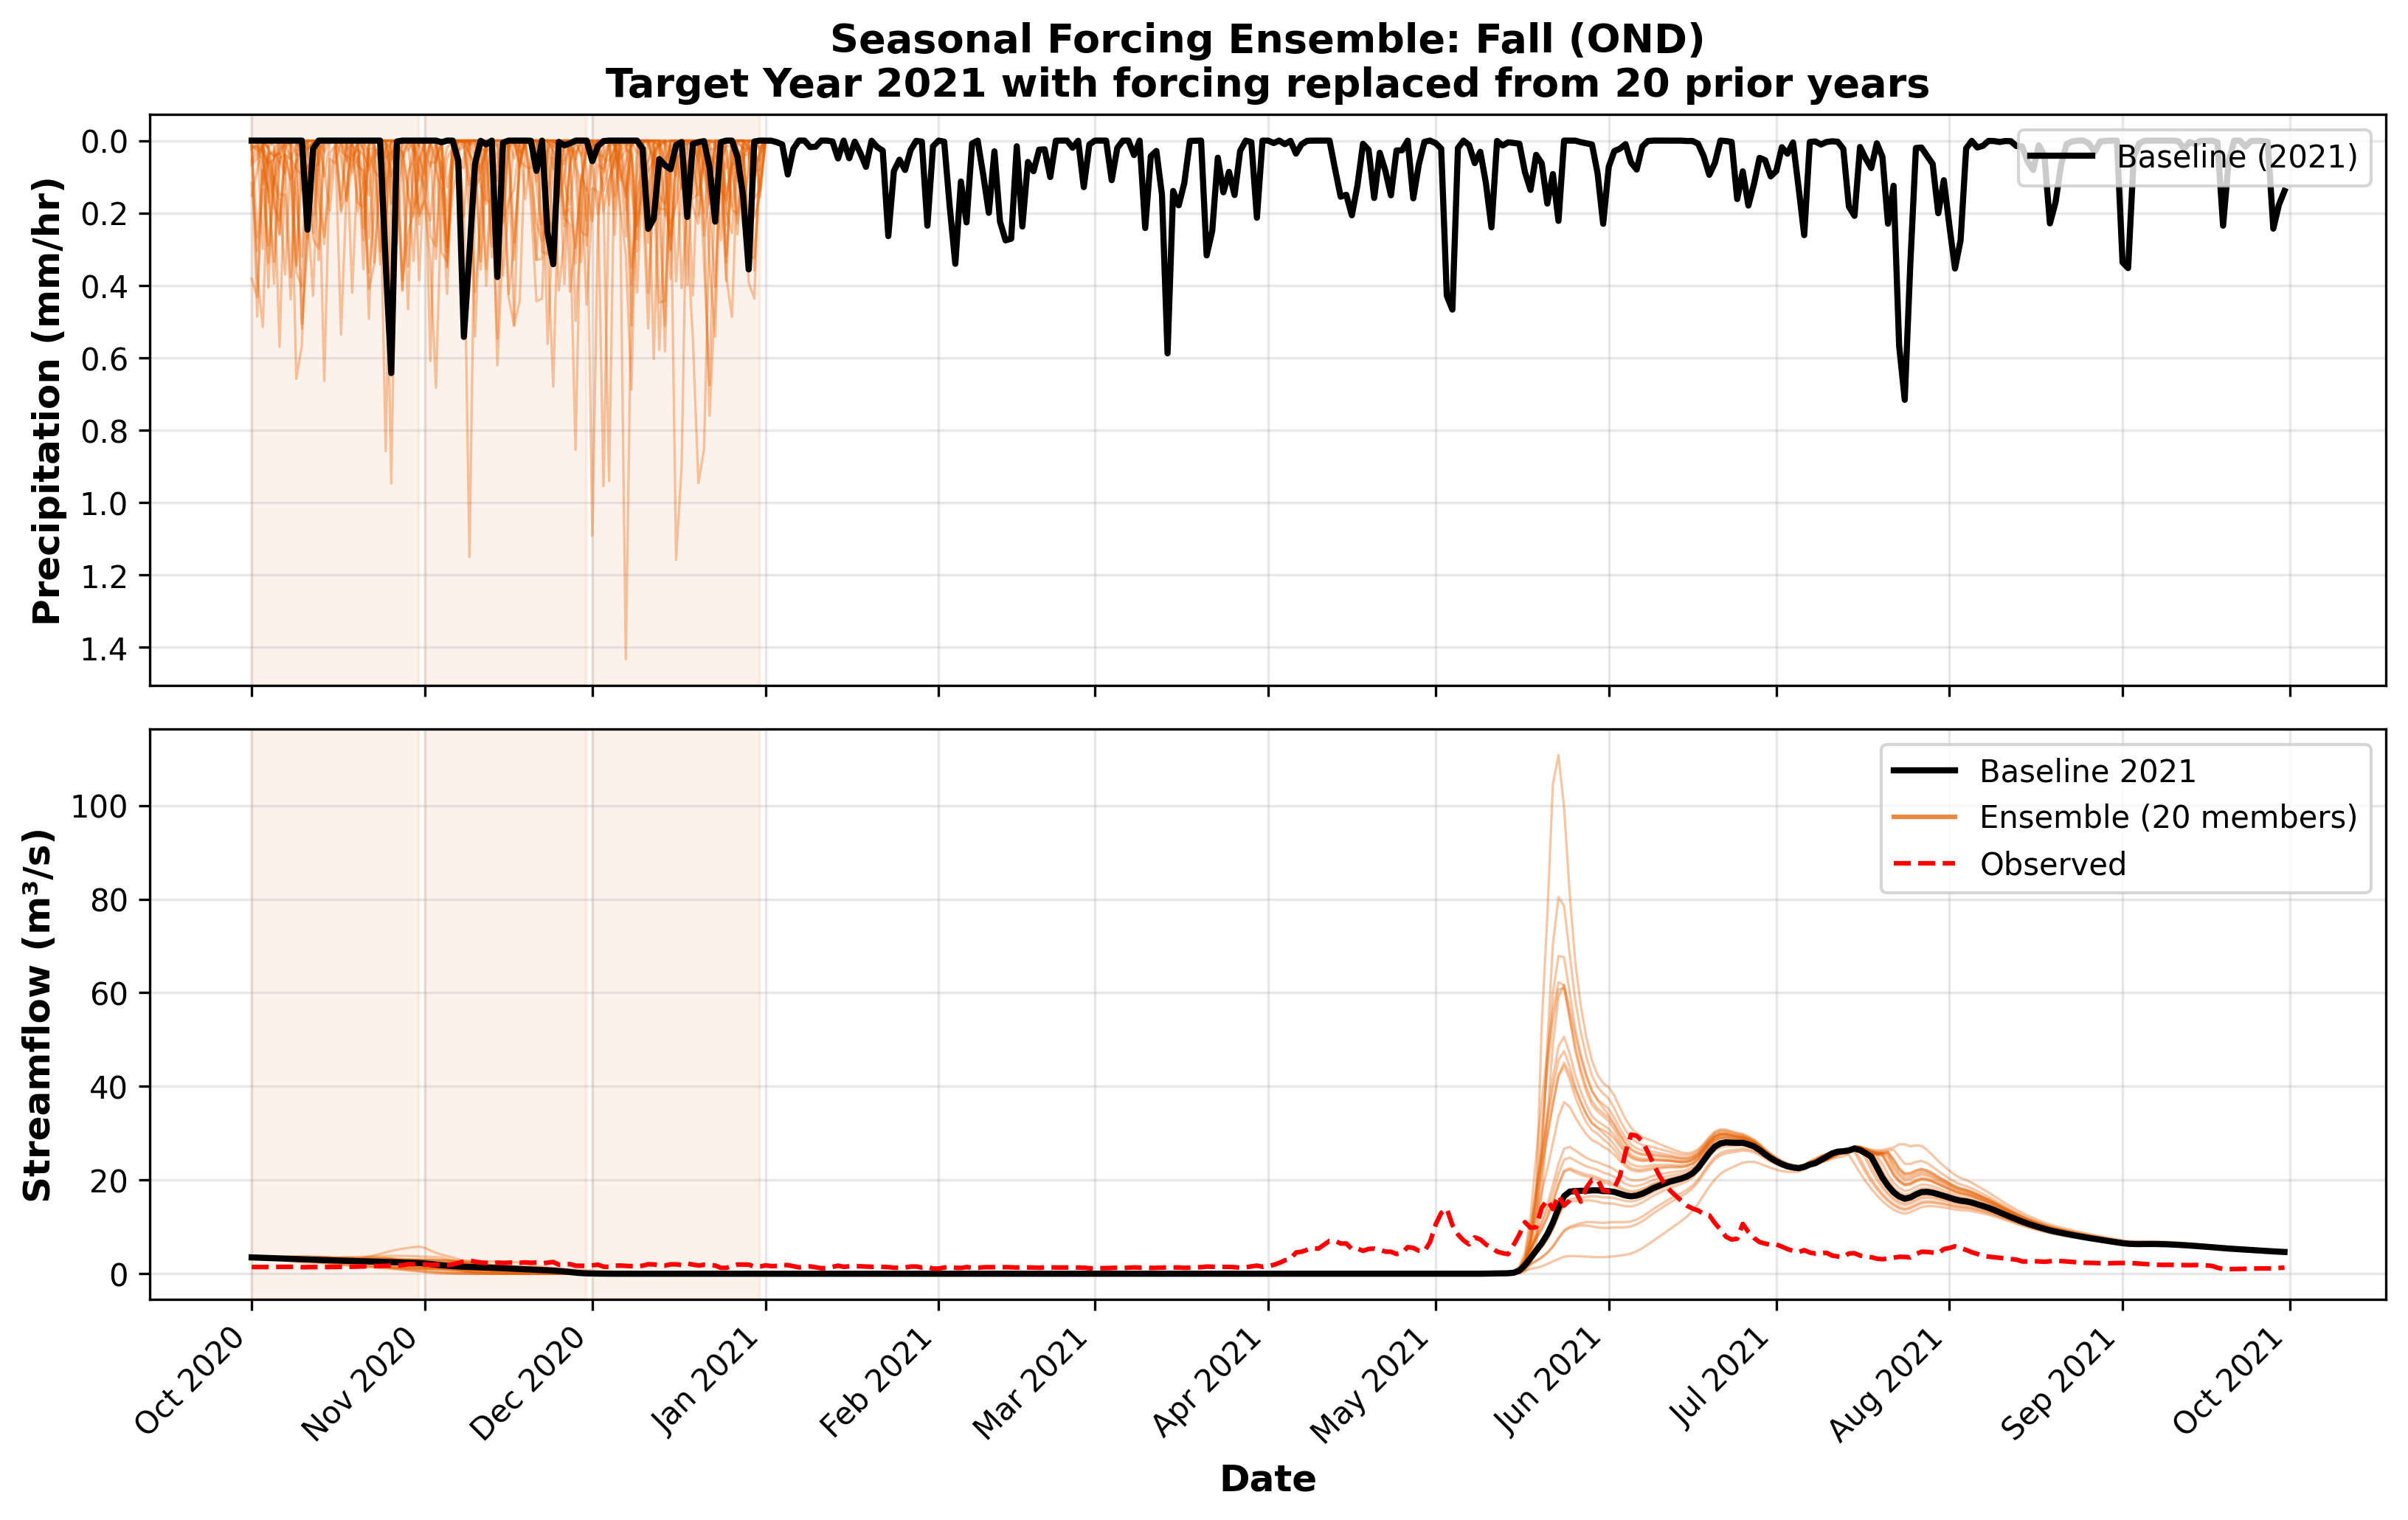


JFM (Winter)


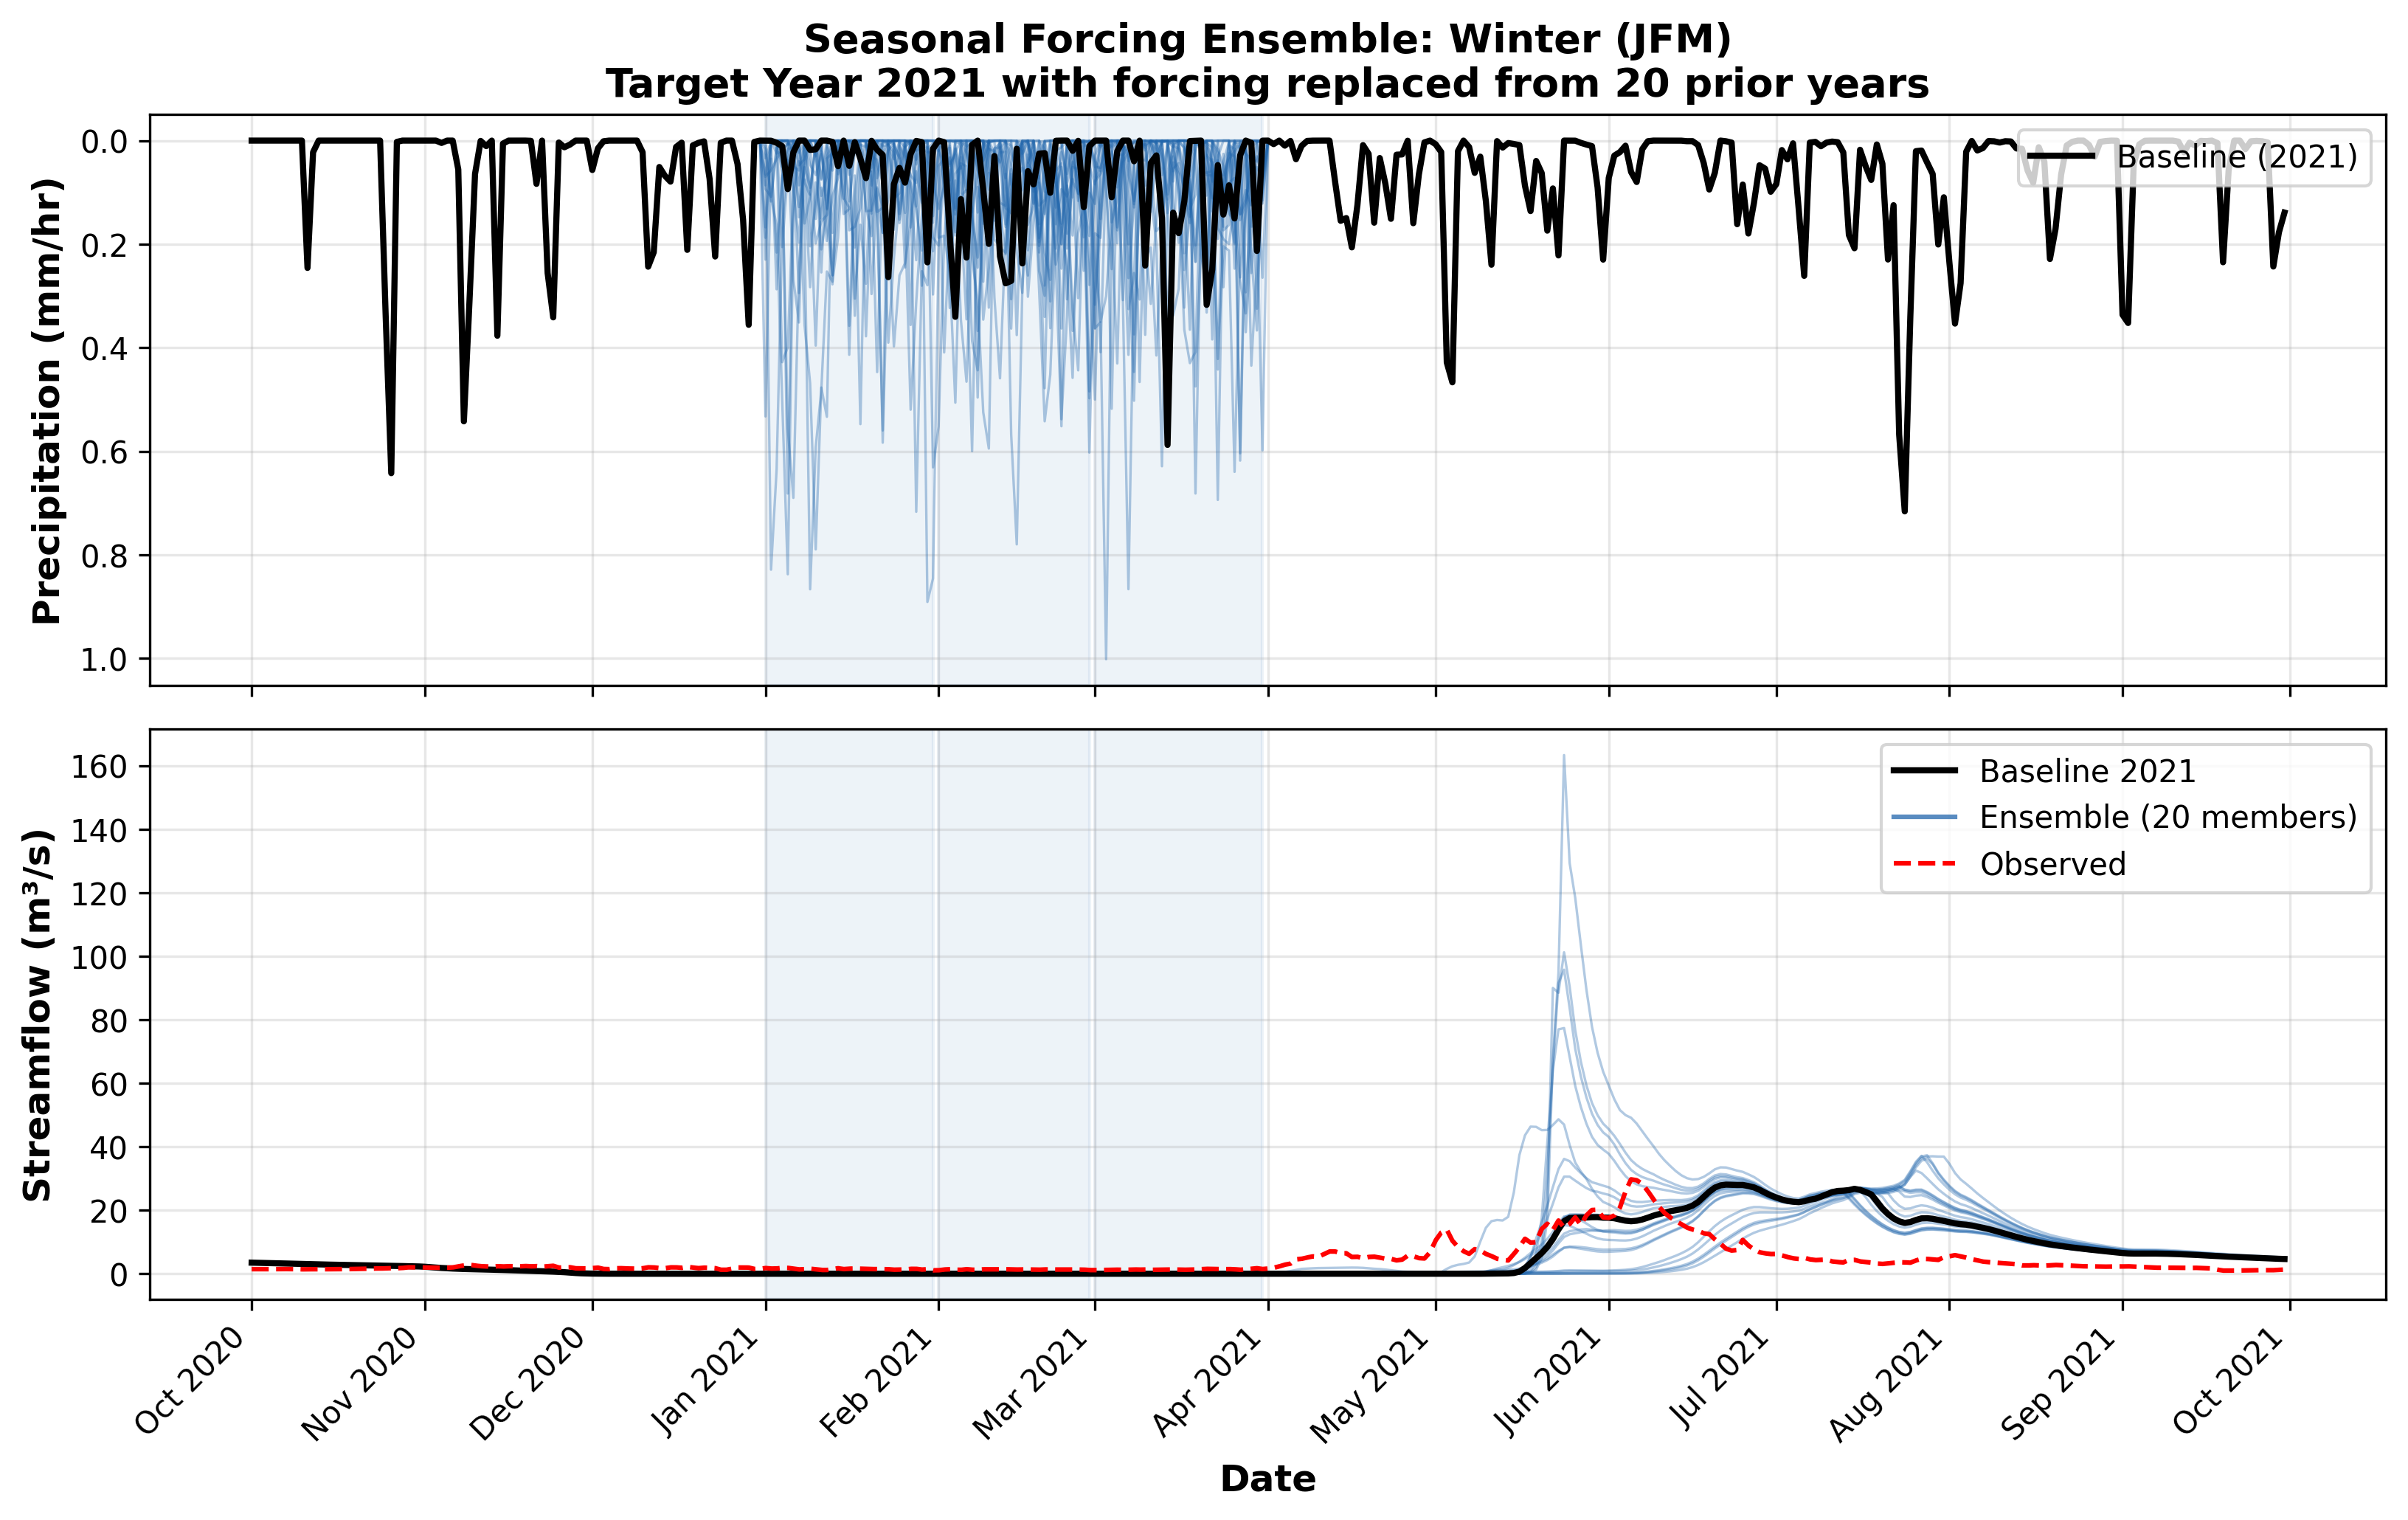


AMJ (Spring)


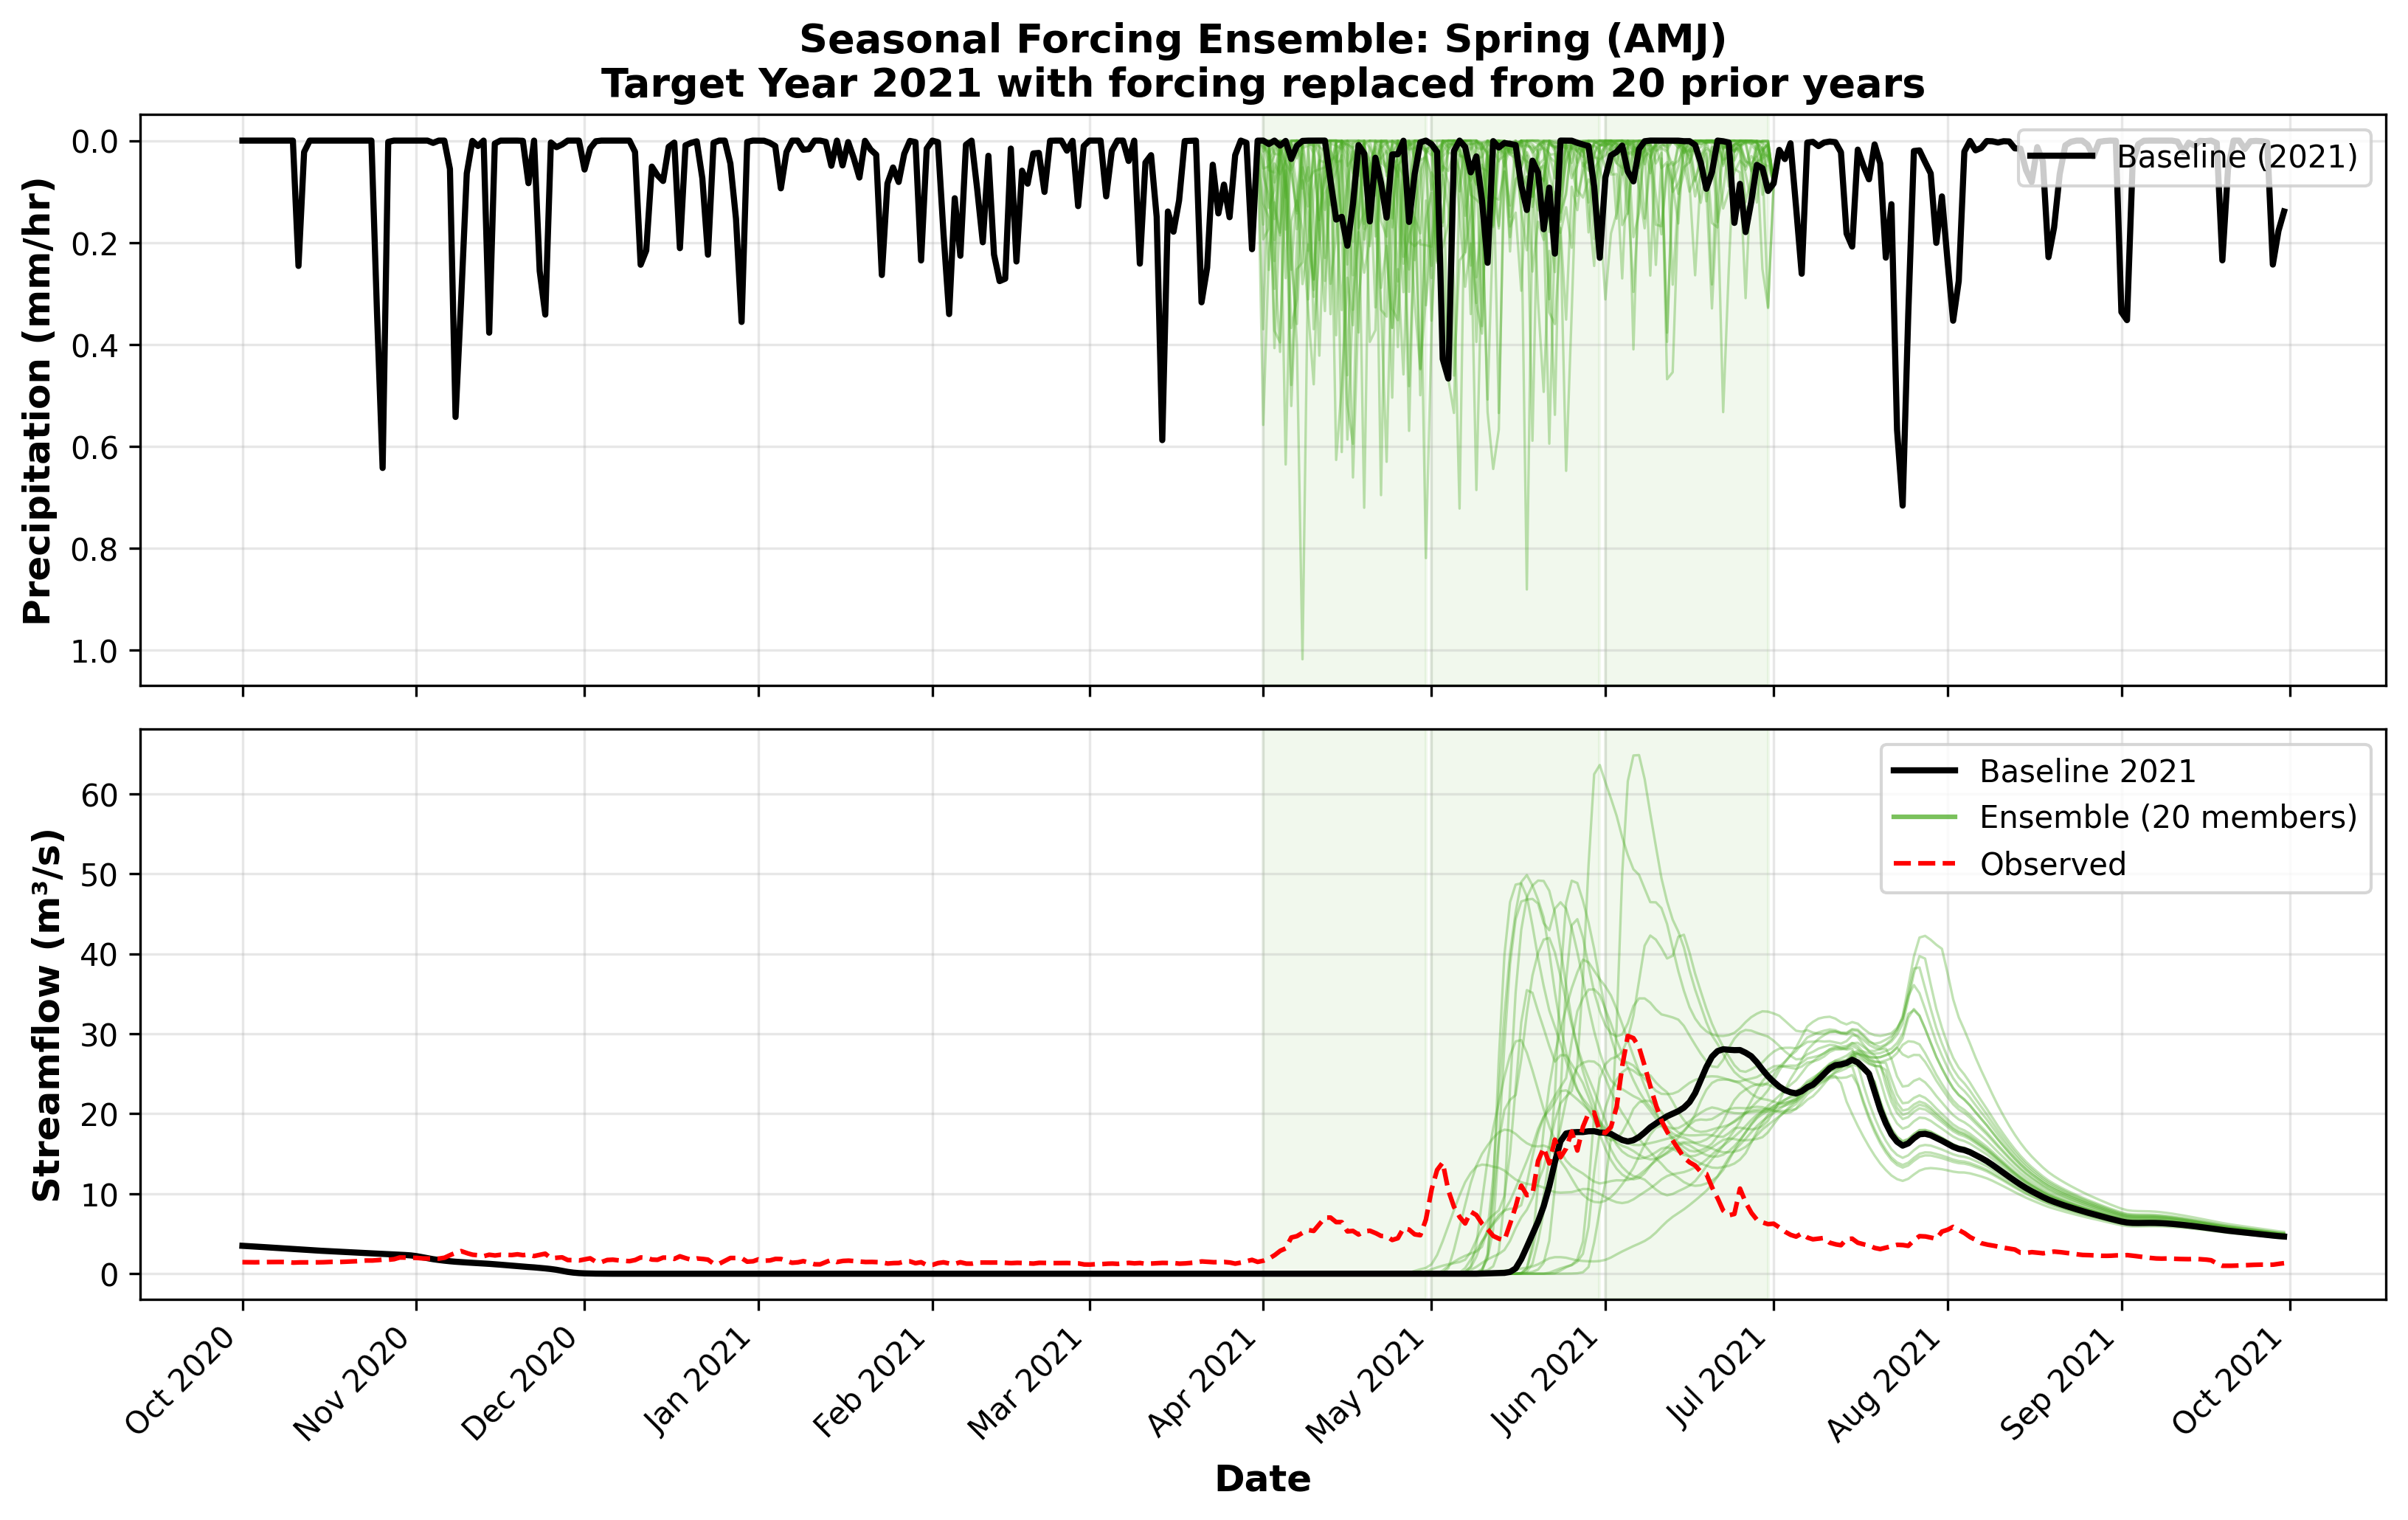


JAS (Summer)


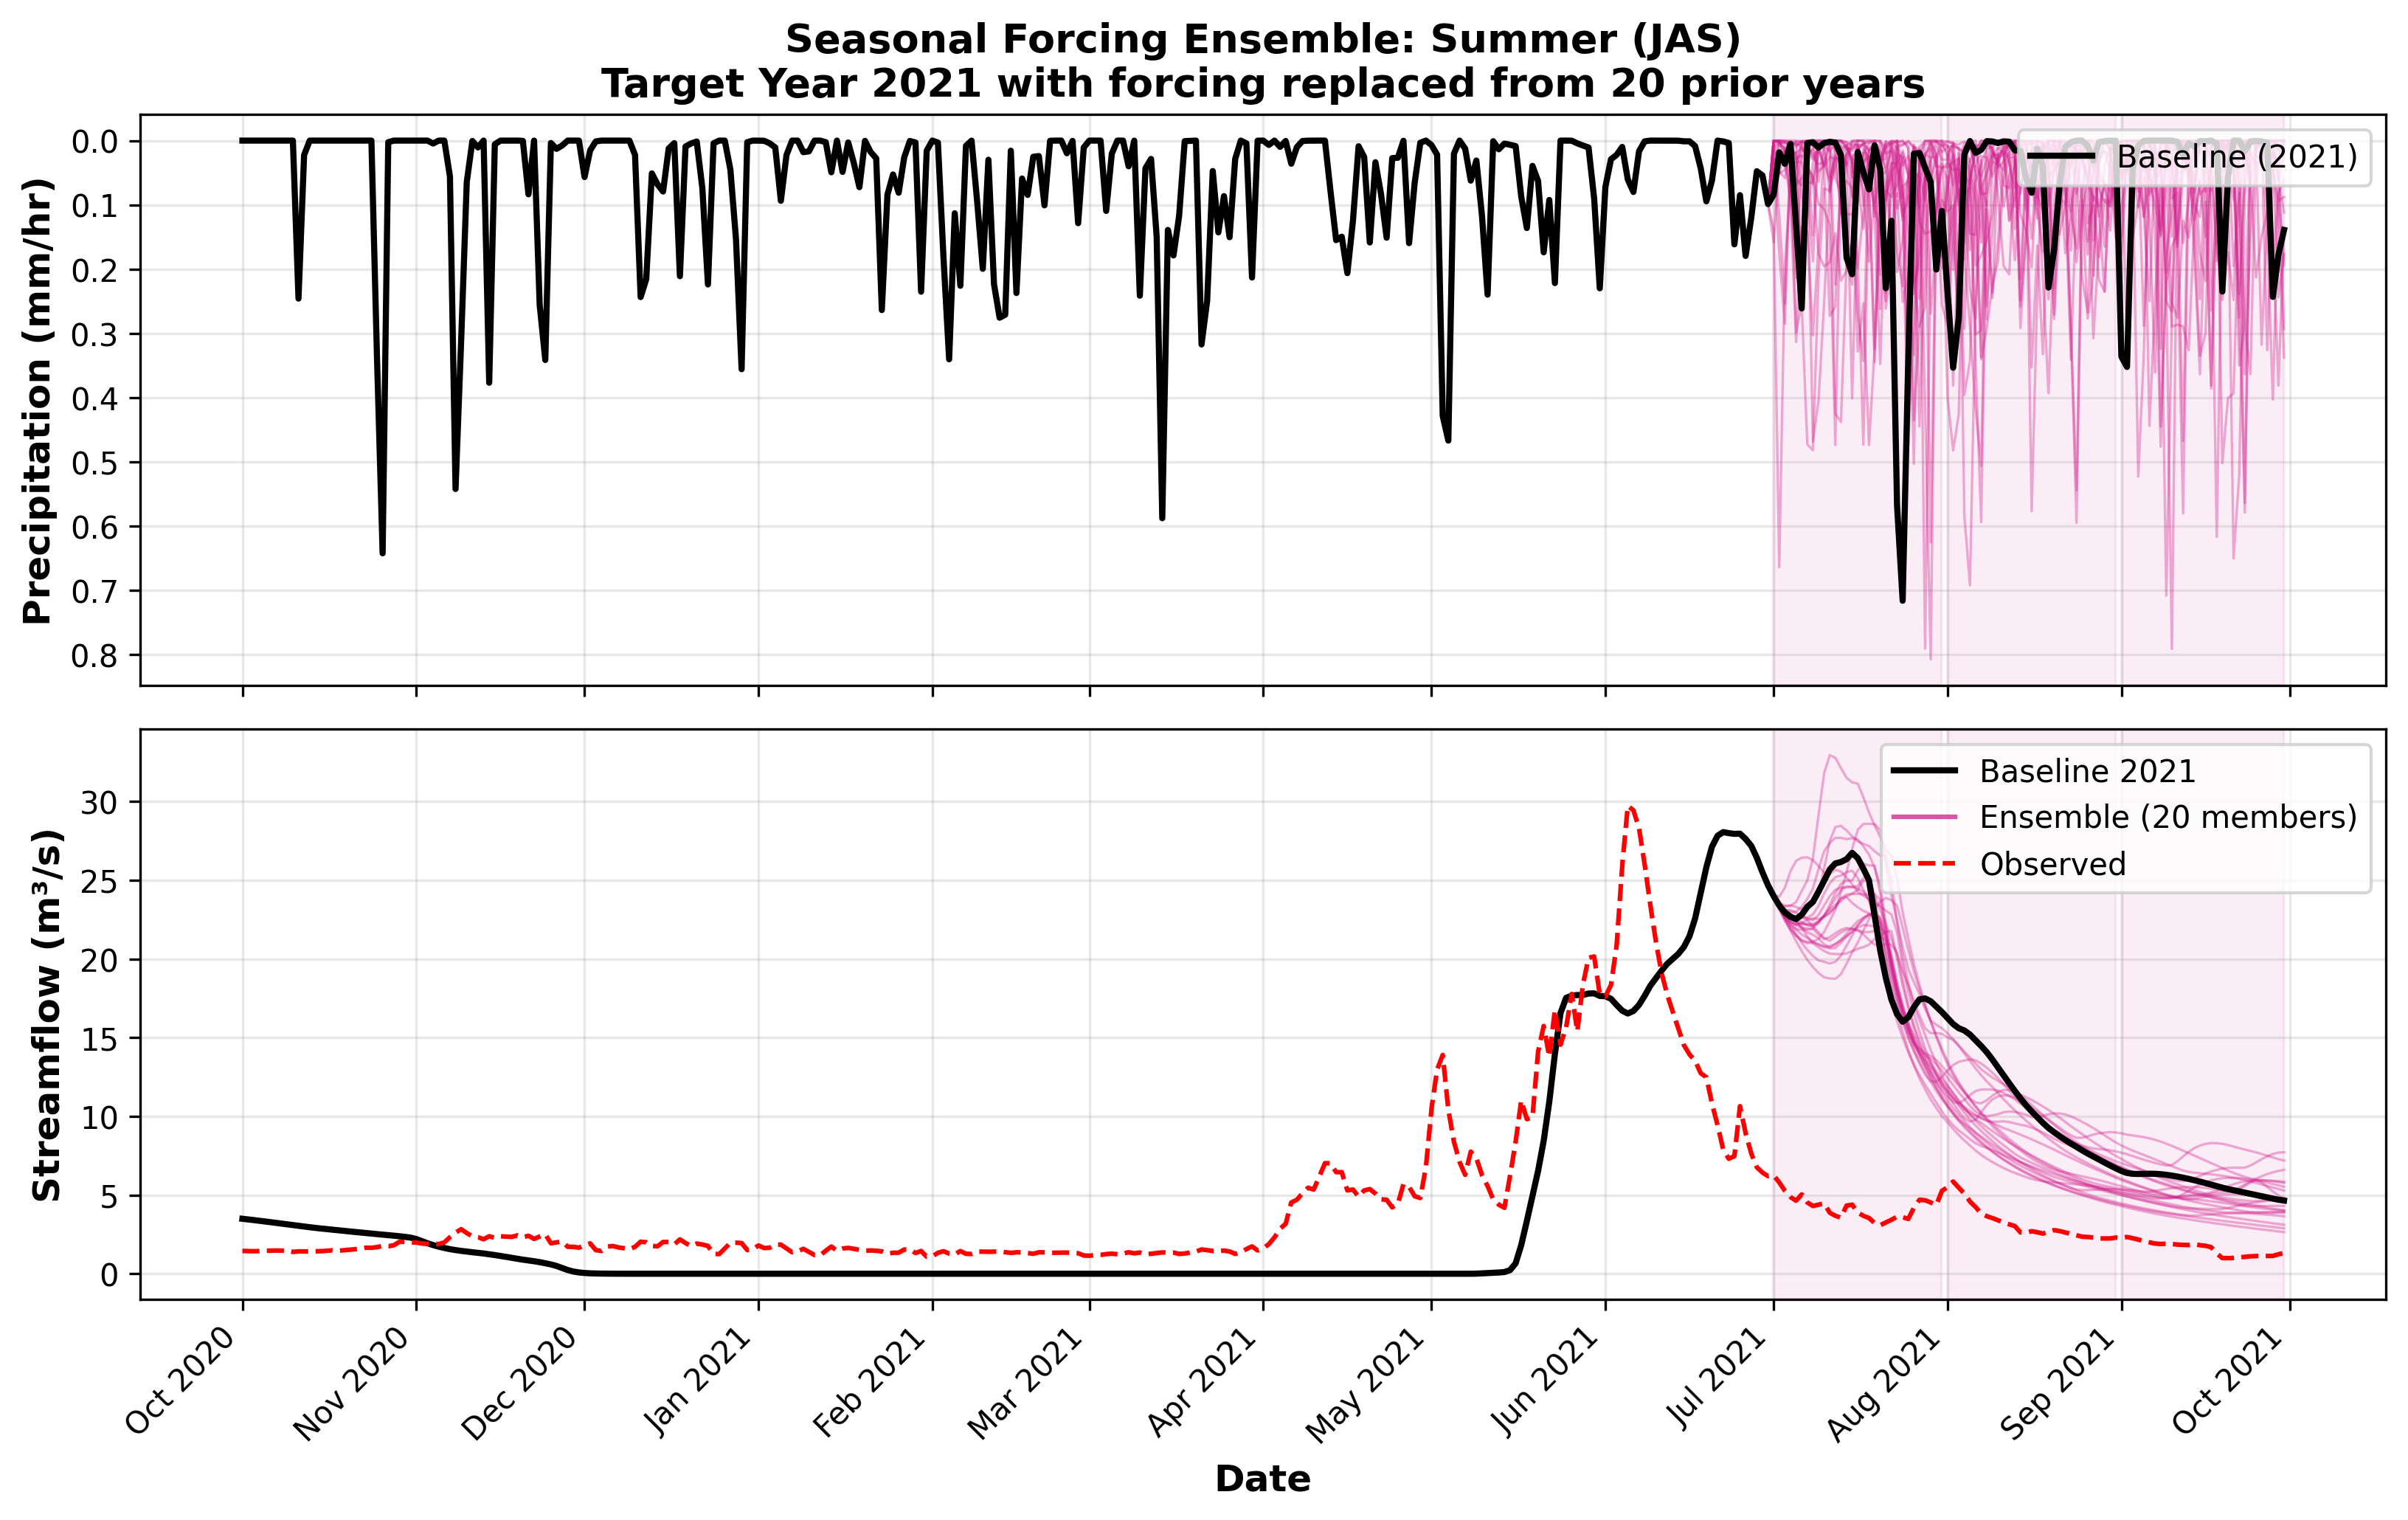

In [23]:
from IPython.display import Image, display as ipy_display

for season in SEASONS:
    plot_file = exp.cfg.plots_dir / f'spaghetti_{season}_{TARGET_YEAR}.png'
    if plot_file.exists():
        print(f"\n{'=' * 50}")
        print(f"{season} ({SEASONS[season]['name']})")
        print(f"{'=' * 50}")
        ipy_display(Image(filename=str(plot_file), width=900))

### 8c. Combined 4-Season Spaghetti Plot

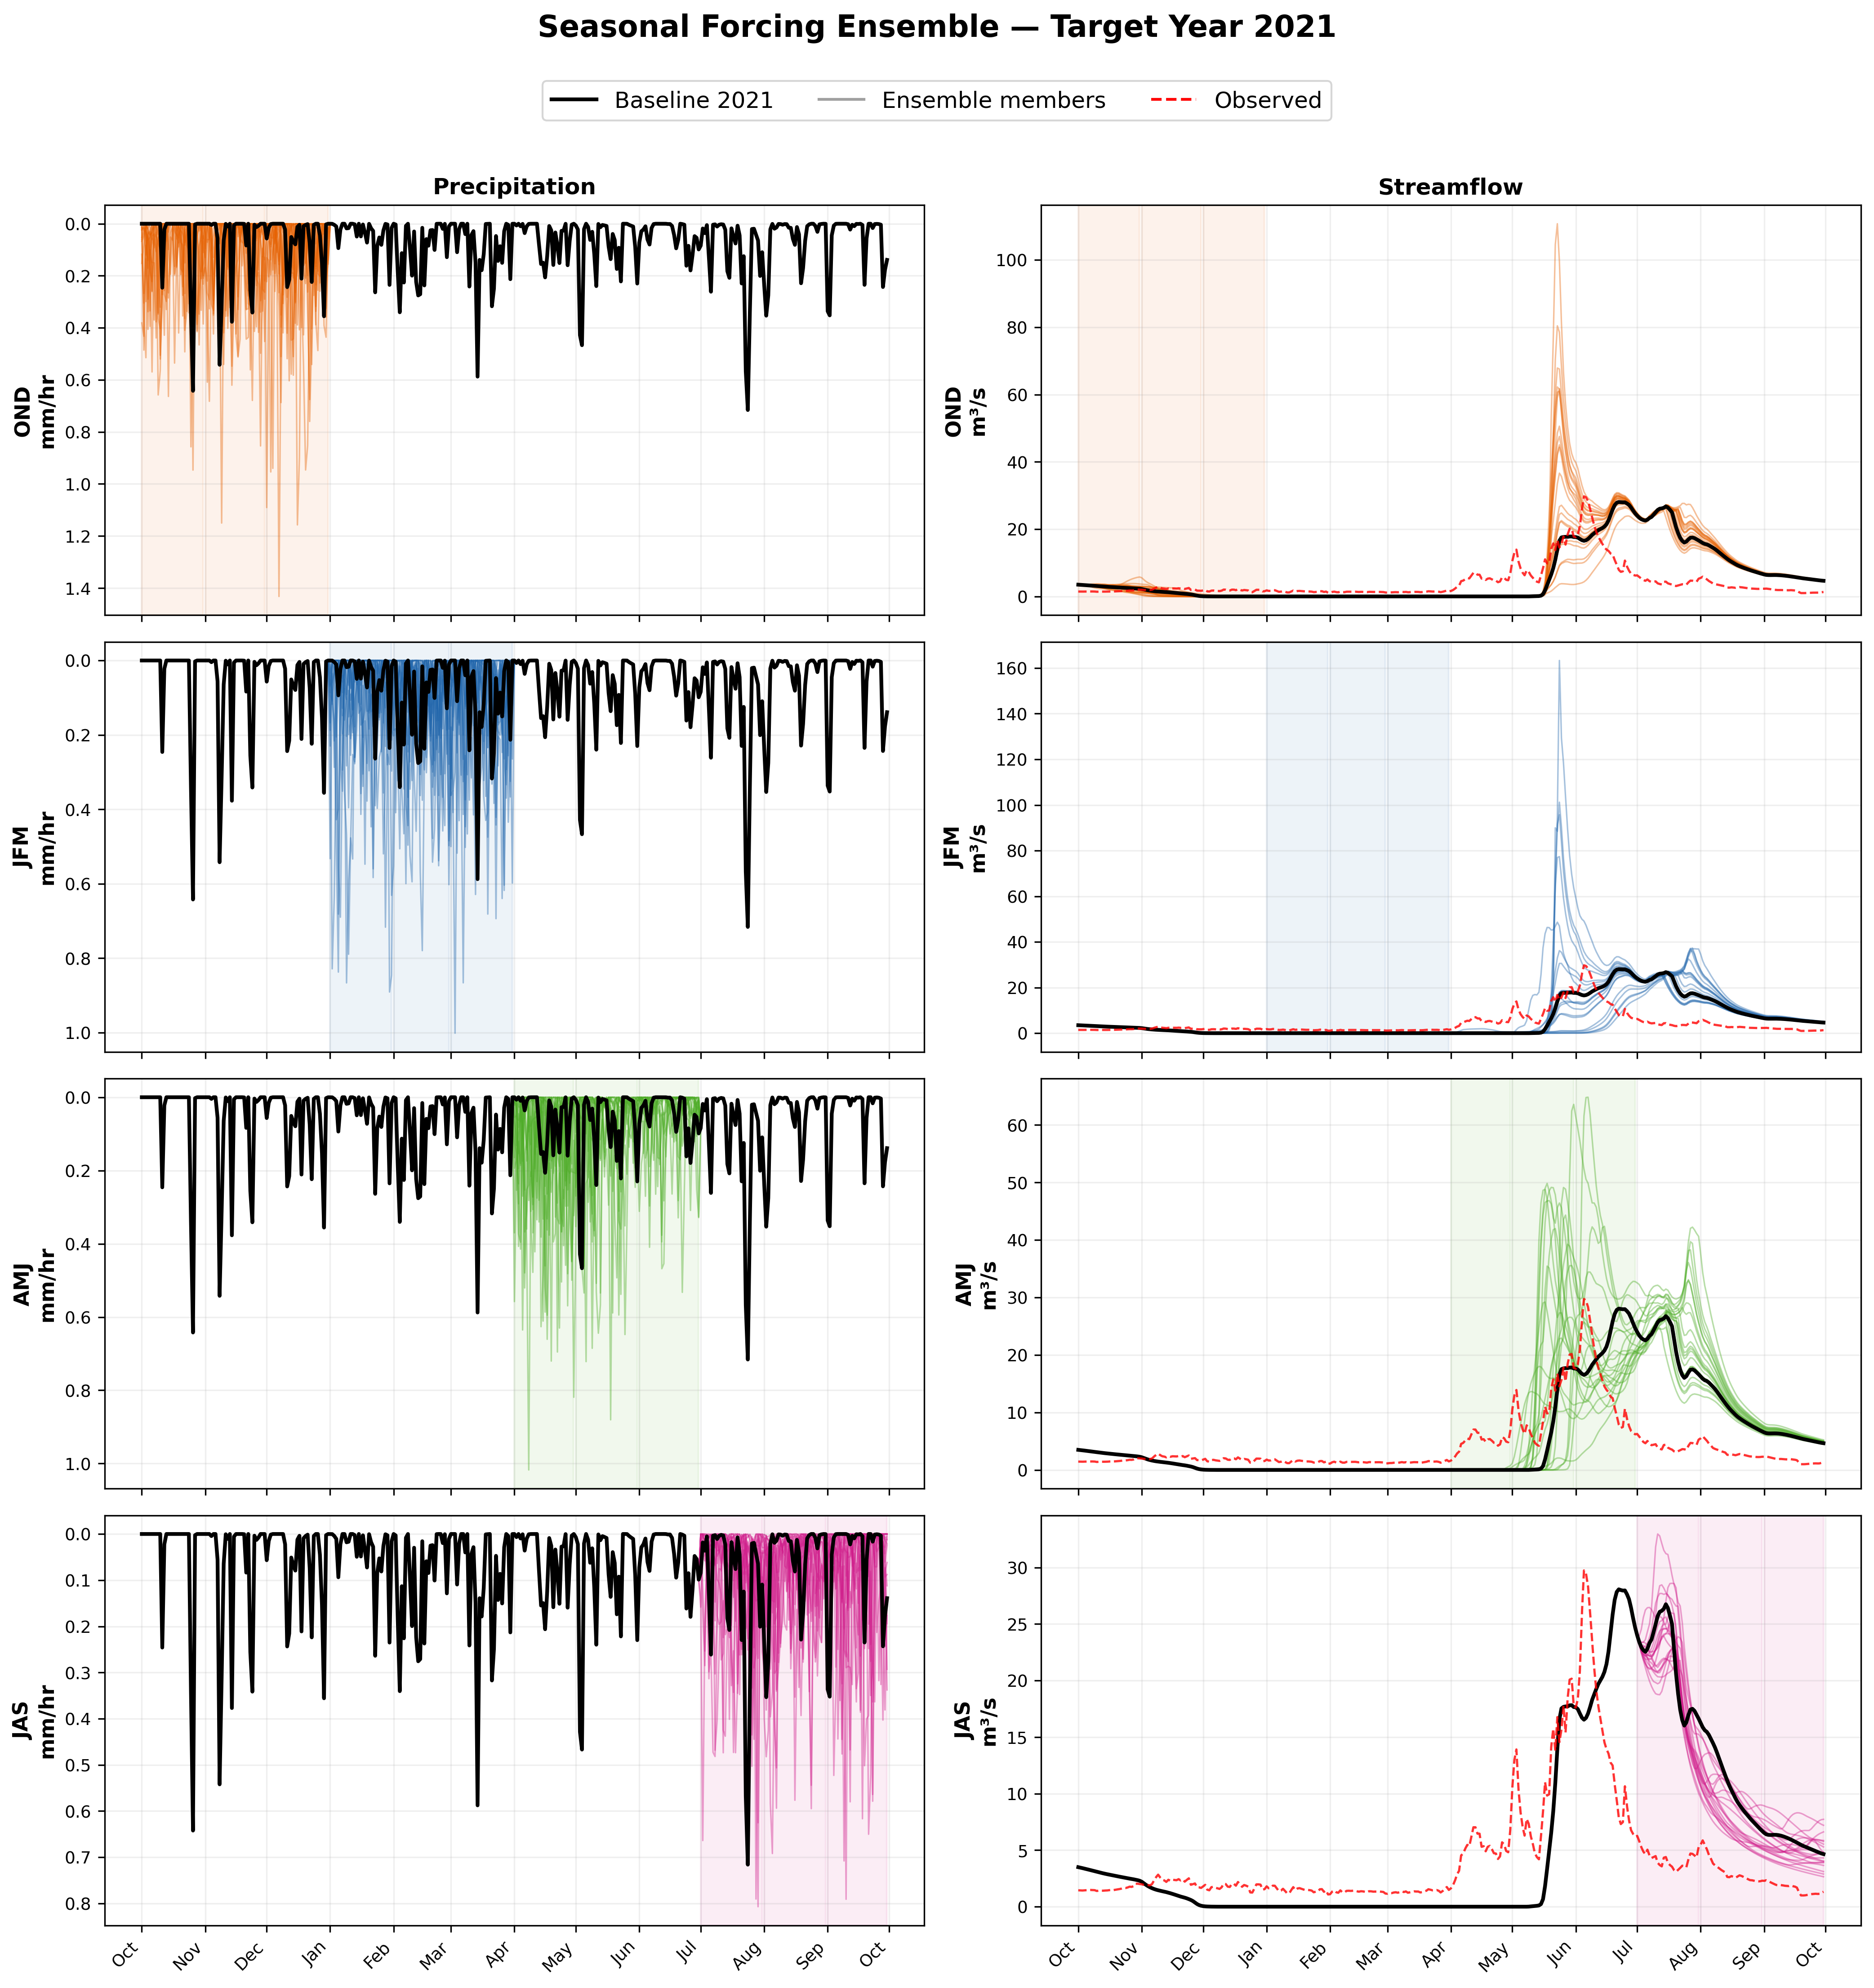

In [24]:
combined_plot = exp.cfg.plots_dir / f'combined_spaghetti_{TARGET_YEAR}.png'
if combined_plot.exists():
    ipy_display(Image(filename=str(combined_plot), width=1000))

### 8d. Sensitivity Dashboard

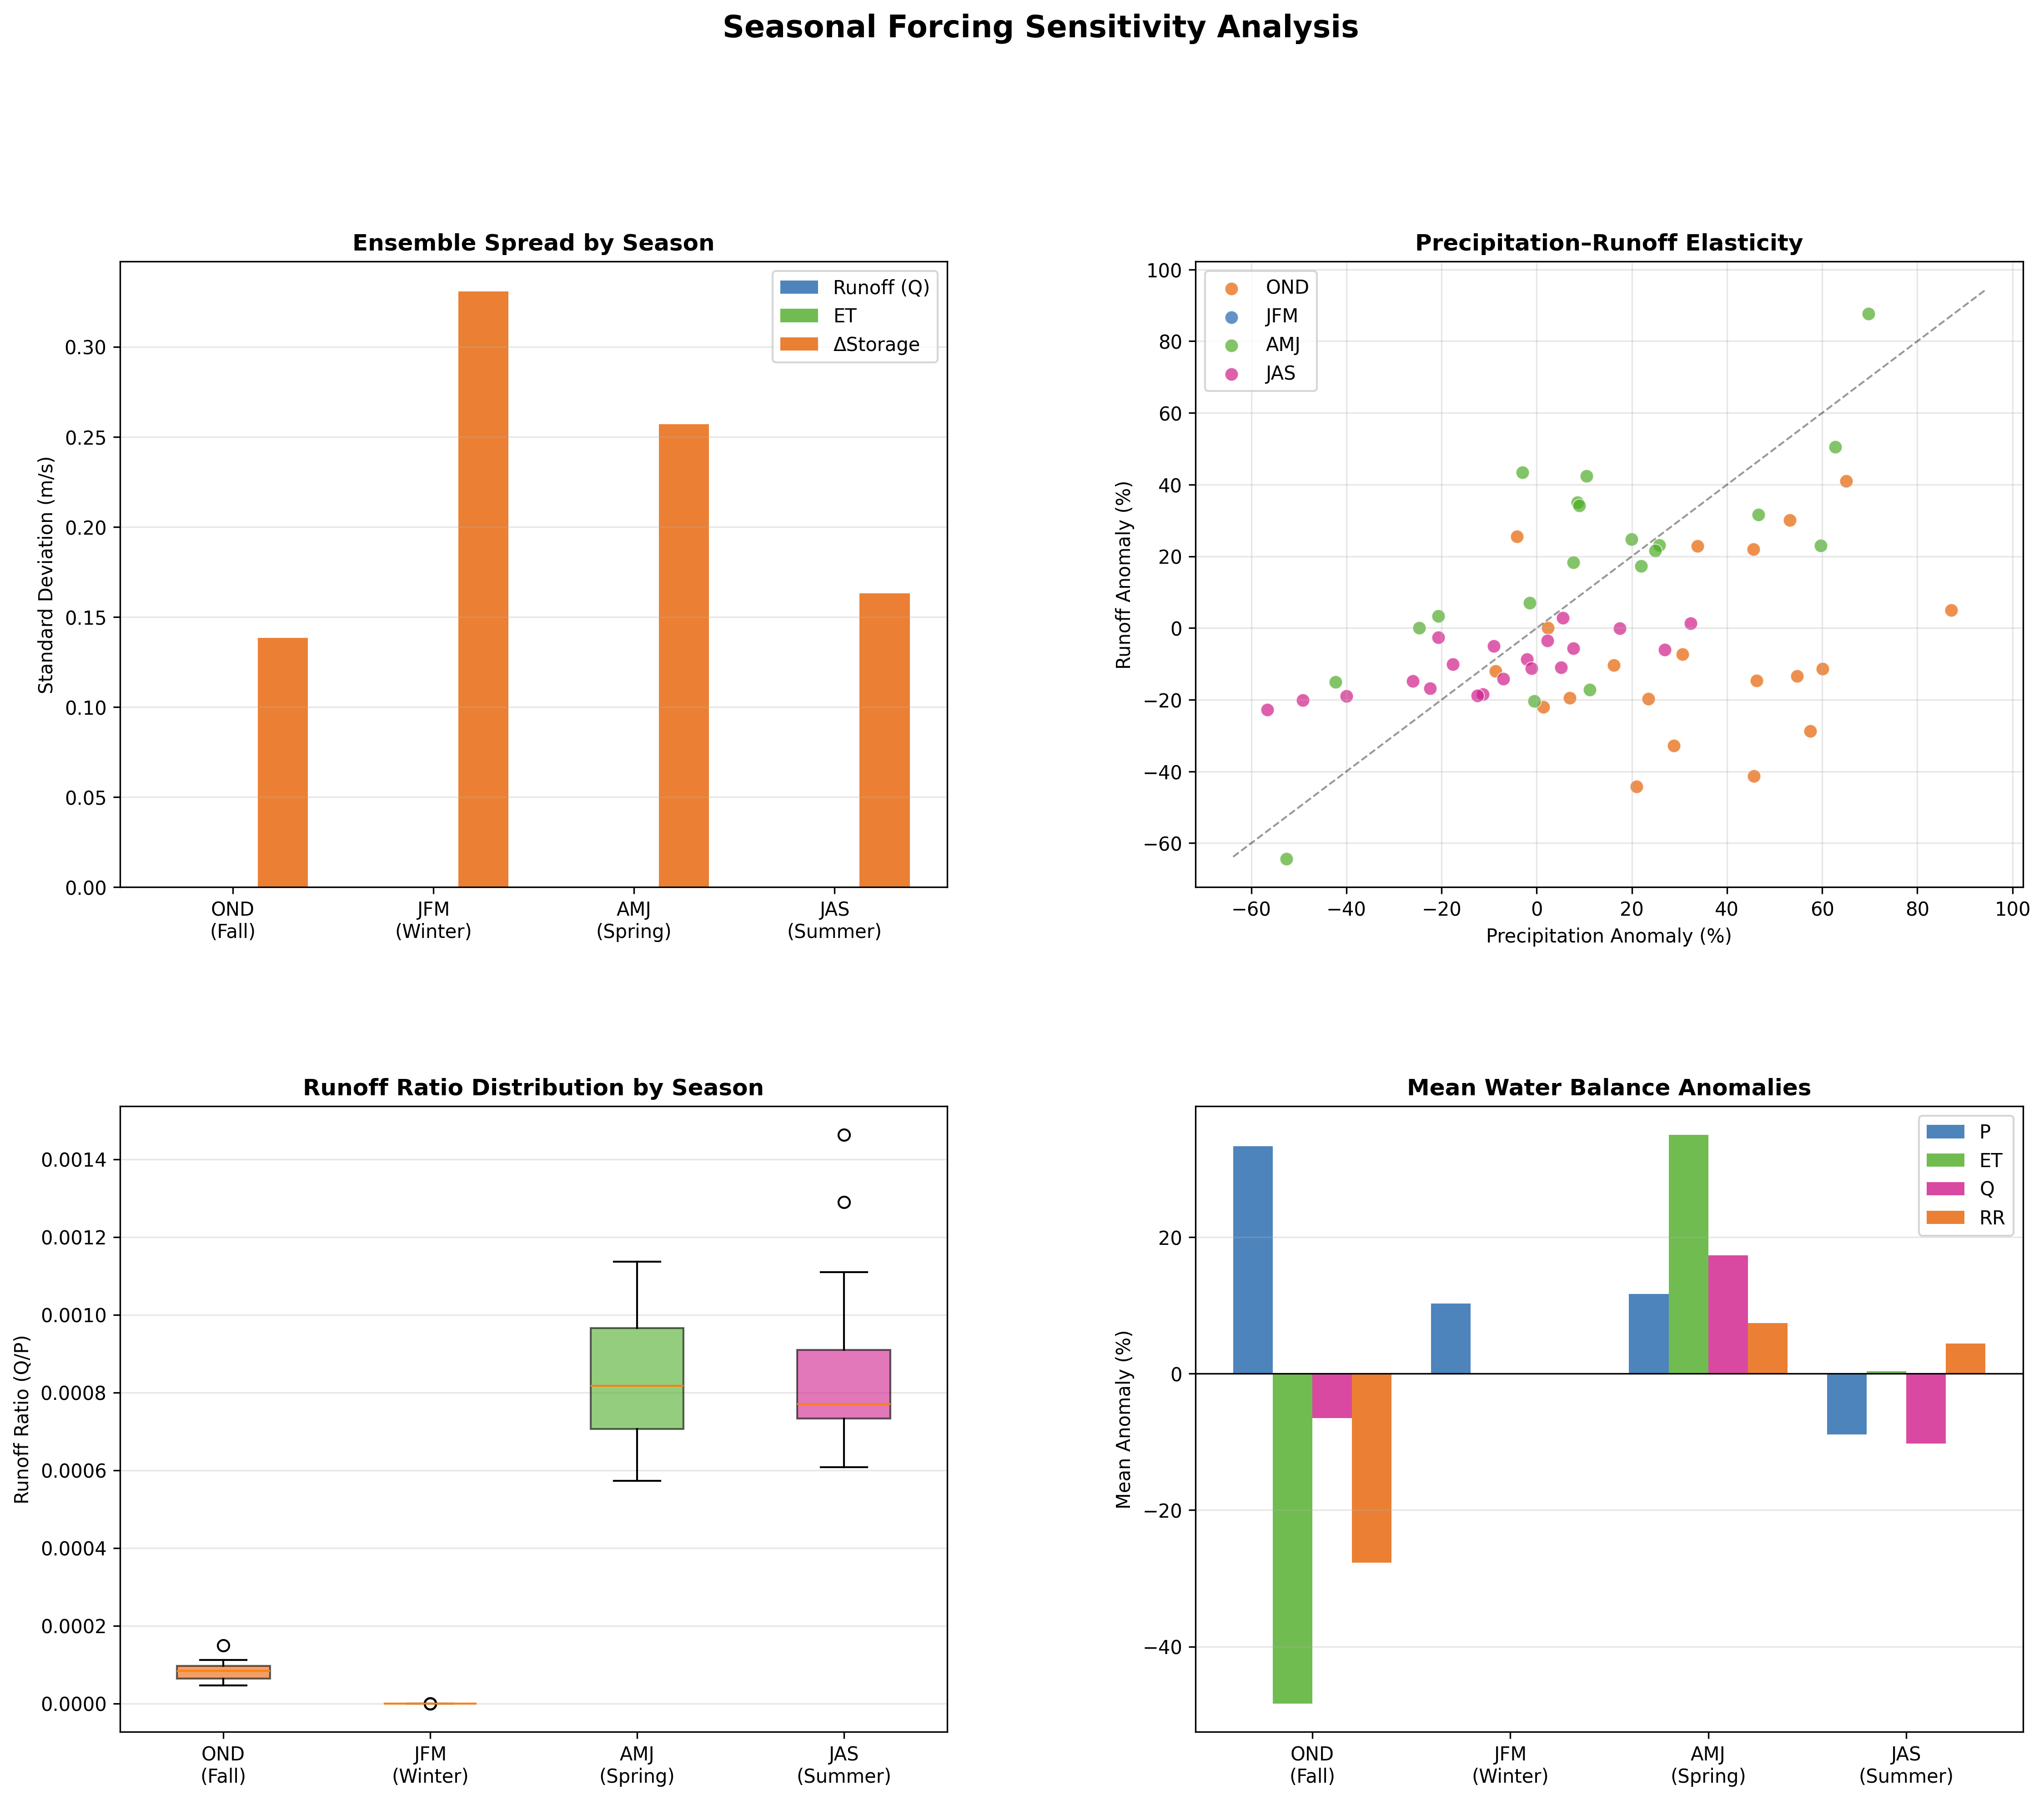

In [25]:
dashboard_plot = exp.cfg.plots_dir / 'sensitivity_dashboard.png'
if dashboard_plot.exists():
    ipy_display(Image(filename=str(dashboard_plot), width=1000))

---
## 9. Detailed Analysis

### 9a. Water Balance Comparison by Season

In [26]:

# Helper function: compute water-year-level metrics from ensemble results
# This converts all metrics to mm and calculates anomalies relative to baseline WY totals

def compute_wy_metrics(baseline_output, ensemble_results, basin_area_m2):
    """
    Compute water-year-level metrics for all ensemble members.
    
    Returns a DataFrame with WY totals (in mm) and anomalies for each member.
    """
    import xarray as xr
    import numpy as np
    from datetime import datetime
    
    wy_data = []
    
    # Load baseline WY output
    ds_baseline = xr.open_dataset(baseline_output)
    baseline_dates = pd.DatetimeIndex(ds_baseline['time'].values)
    
    # Get time step in seconds (typically 3600 for hourly SUMMA output)
    time_diffs = np.diff(ds_baseline['time'].values.astype('datetime64[s]').astype(float))
    dt_sec = time_diffs[0] if len(time_diffs) > 0 else 3600  # default to 1 hour if can't determine
    
    # Calculate baseline WY metrics
    # pptrate is in kg/m²/s; multiply by dt_sec to get kg/m² (= mm)
    baseline_P = (ds_baseline['pptrate'].sum() * dt_sec).values  # convert kg/m²/s to mm
    baseline_Q = (ds_baseline['scalarTotalRunoff'].sum() * 1000 * dt_sec).values  # m/s * s converted to mm integrated
    baseline_ET = (-ds_baseline['scalarTotalET'].sum() * dt_sec).values  # convert kg/m²/s to mm
    baseline_SWE = (ds_baseline.get('scalarSWE', ds_baseline.get('scalarSWEchange', 0)).isel(time=-1).values - 
                   ds_baseline.get('scalarSWE', ds_baseline.get('scalarSWEchange', 0)).isel(time=0).values) * 1000
    baseline_dS = baseline_SWE  # simplified: just use SWE change
    
    # Baseline row
    wy_data.append({
        'season': 'baseline',
        'donor_year': 'baseline',
        'P_mm': baseline_P,
        'Q_mm': baseline_Q,
        'ET_mm': baseline_ET,
        'dS_mm': baseline_dS,
        'RR': baseline_Q / baseline_P if baseline_P > 0 else 0,
    })
    
    # Process each ensemble member
    for season, season_results in ensemble_results.items():
        for donor_year, member_output in season_results.items():
            try:
                ds_member = xr.open_dataset(member_output)
                
                member_P = (ds_member['pptrate'].sum() * dt_sec).values
                member_Q = (ds_member['scalarTotalRunoff'].sum() * 1000 * dt_sec ).values
                member_ET = (-ds_member['scalarTotalET'].sum() * dt_sec).values
                member_SWE = (ds_member.get('scalarSWE', ds_member.get('scalarSWEchange', 0)).isel(time=-1).values - 
                             ds_member.get('scalarSWE', ds_member.get('scalarSWEchange', 0)).isel(time=0).values) * 1000
                member_dS = member_SWE
                
                wy_data.append({
                    'season': season,
                    'donor_year': donor_year,
                    'P_mm': member_P,
                    'Q_mm': member_Q,
                    'ET_mm': member_ET,
                    'dS_mm': member_dS,
                    'RR': member_Q / member_P if member_P > 0 else 0,
                })
                ds_member.close()
            except Exception as e:
                print(f"  WARNING: could not process {season}/{donor_year}: {e}")
                continue
    
    ds_baseline.close()
    
    wy_df = pd.DataFrame(wy_data)
    
    # Calculate anomalies relative to baseline
    baseline_row = wy_df[wy_df['season'] == 'baseline'].iloc[0]
    wy_df['P_anom_mm'] = wy_df['P_mm'] - baseline_row['P_mm']
    wy_df['Q_anom_mm'] = wy_df['Q_mm'] - baseline_row['Q_mm']
    wy_df['ET_anom_mm'] = wy_df['ET_mm'] - baseline_row['ET_mm']
    wy_df['dS_anom_mm'] = wy_df['dS_mm'] - baseline_row['dS_mm']
    wy_df['RR_anom'] = wy_df['RR'] - baseline_row['RR']
    
    # Calculate percent anomalies
    wy_df['P_anom_pct'] = 100 * wy_df['P_anom_mm'] / baseline_row['P_mm']
    wy_df['Q_anom_pct'] = 100 * wy_df['Q_anom_mm'] / baseline_row['Q_mm']
    wy_df['ET_anom_pct'] = 100 * wy_df['ET_anom_mm'] / baseline_row['ET_mm']
    
    # Calculate elasticity at WY level
    wy_df['Q_per_P'] = wy_df['Q_mm'] / wy_df['P_mm']
    
    return wy_df

# Compute WY metrics (only if we have baseline and ensemble results)
if 'ensemble_results' in locals() and ensemble_results:
    print("Computing water-year-level metrics...")
    wy_df = compute_wy_metrics(exp.target_baseline_output, ensemble_results, exp.cfg.basin_area_m2)
    wy_baseline = wy_df[wy_df['season'] == 'baseline'].iloc[0]
    print(f"\nBaseline WY totals:")
    print(f"  Precipitation: {wy_baseline['P_mm']:.1f} mm")
    print(f"  Runoff: {wy_baseline['Q_mm']:.1f} mm")
    print(f"  ET: {wy_baseline['ET_mm']:.1f} mm")
    print(f"  Runoff Ratio: {wy_baseline['RR']:.3f}")
else:
    print("No ensemble results loaded - skipping WY metric computation")


Computing water-year-level metrics...

Baseline WY totals:
  Precipitation: 582.1 mm
  Runoff: 250.1 mm
  ET: 244.5 mm
  Runoff Ratio: 0.430


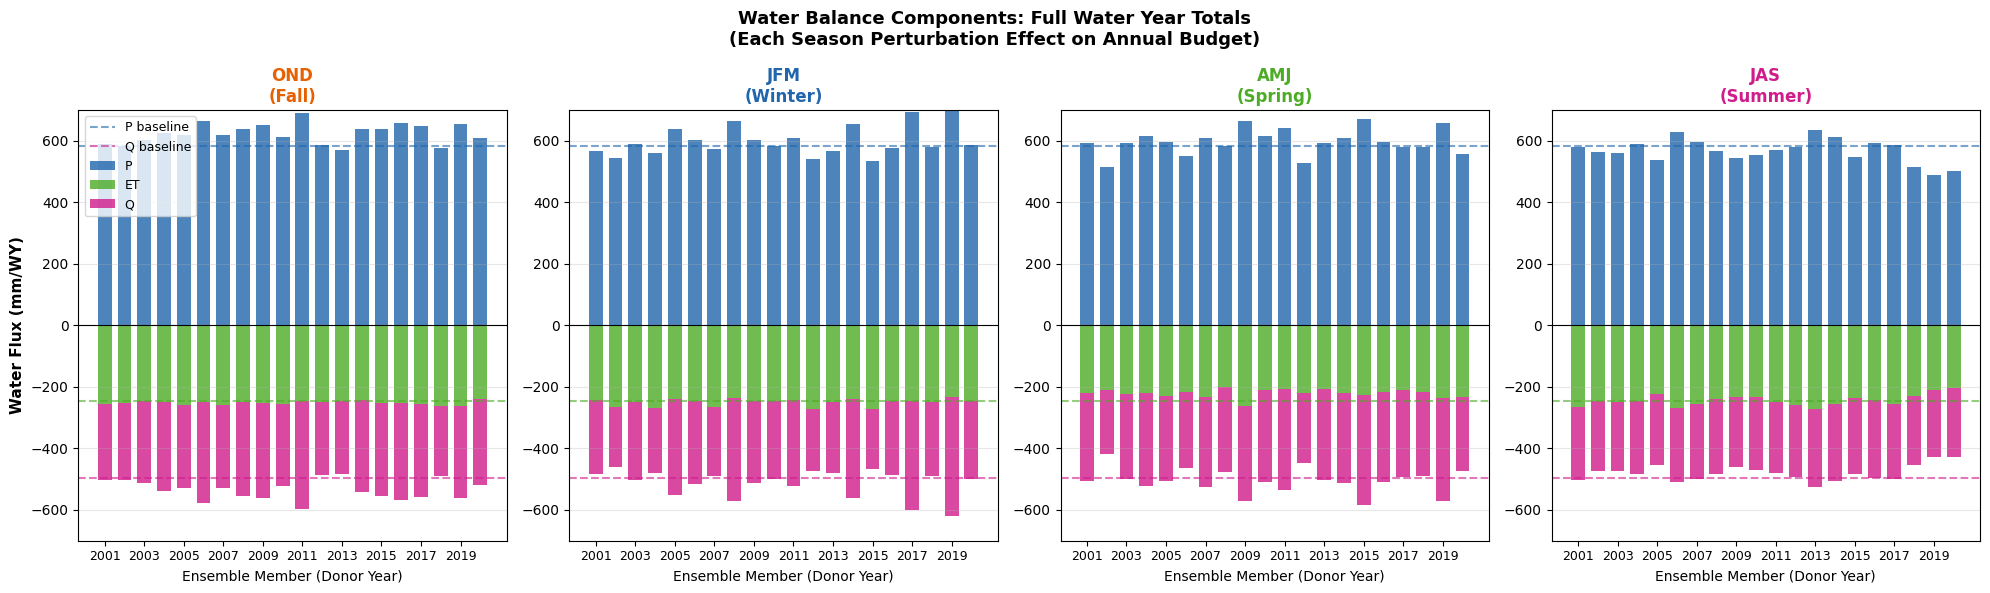

In [30]:
# Water balance: annual (WY) totals for each ensemble member, arranged by season
# Each panel shows how that season's perturbation affects the full-year water balance

if 'wy_df' not in locals():
    print("WY metrics not computed yet - run the helper cell above first")
else:
    fig, axes = plt.subplots(1, 4, figsize=(20, 6))
    
    for i, season in enumerate(SEASONS):
        ax = axes[i]
        season_data = wy_df[(wy_df['season'] == season) & (wy_df['season'] != 'baseline')].copy()
        
        if season_data.empty:
            ax.set_title(f'{season} (no data)')
            continue
        
        season_data = season_data.sort_values('donor_year')
        x = np.arange(len(season_data))
        width = 0.25
        
        # Stacked bar: P (blue), then subtract ET (green) and Q (pink) from top
        bars_p = ax.bar(x, season_data['P_mm'], width=0.7, alpha=0.8, label='P', color='#2166ac')
        bars_et = ax.bar(x, -season_data['ET_mm'], width=0.7, alpha=0.8, label='ET', color='#4dac26')
        bars_q = ax.bar(x, -season_data['Q_mm'], width=0.7, alpha=0.8, label='Q', 
                       color='#d01c8b', bottom=-season_data['ET_mm'])
        
        # Add baseline reference lines
        ax.axhline(wy_baseline['P_mm'], color='#2166ac', linestyle='--', linewidth=1.5, alpha=0.6, label='P baseline')
        ax.axhline(-wy_baseline['ET_mm'], color='#4dac26', linestyle='--', linewidth=1.5, alpha=0.6)
        ax.axhline(-wy_baseline['Q_mm'] - wy_baseline['ET_mm'], color='#d01c8b', linestyle='--', linewidth=1.5, alpha=0.6, label='Q baseline')
        
        ax.set_title(f"{season}\n({SEASONS[season]['name']})", fontweight='bold', fontsize=12,
                    color=SEASONS[season]['color'])
        ax.set_xlabel('Ensemble Member (Donor Year)', fontsize=10)
        ax.axhline(0, color='black', linewidth=0.8)
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_ylim(-700, 700)
        ax.set_xticks(x[::2])
        ax.set_xticklabels(season_data['donor_year'].values[::2], fontsize=9)
        
        if i == 0:
            ax.set_ylabel('Water Flux (mm/WY)', fontsize=11, fontweight='bold')
            ax.legend(loc='upper left', fontsize=9)
    
    plt.suptitle('Water Balance Components: Full Water Year Totals\n(Each Season Perturbation Effect on Annual Budget)', 
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 9b. Runoff Ratio Sensitivity

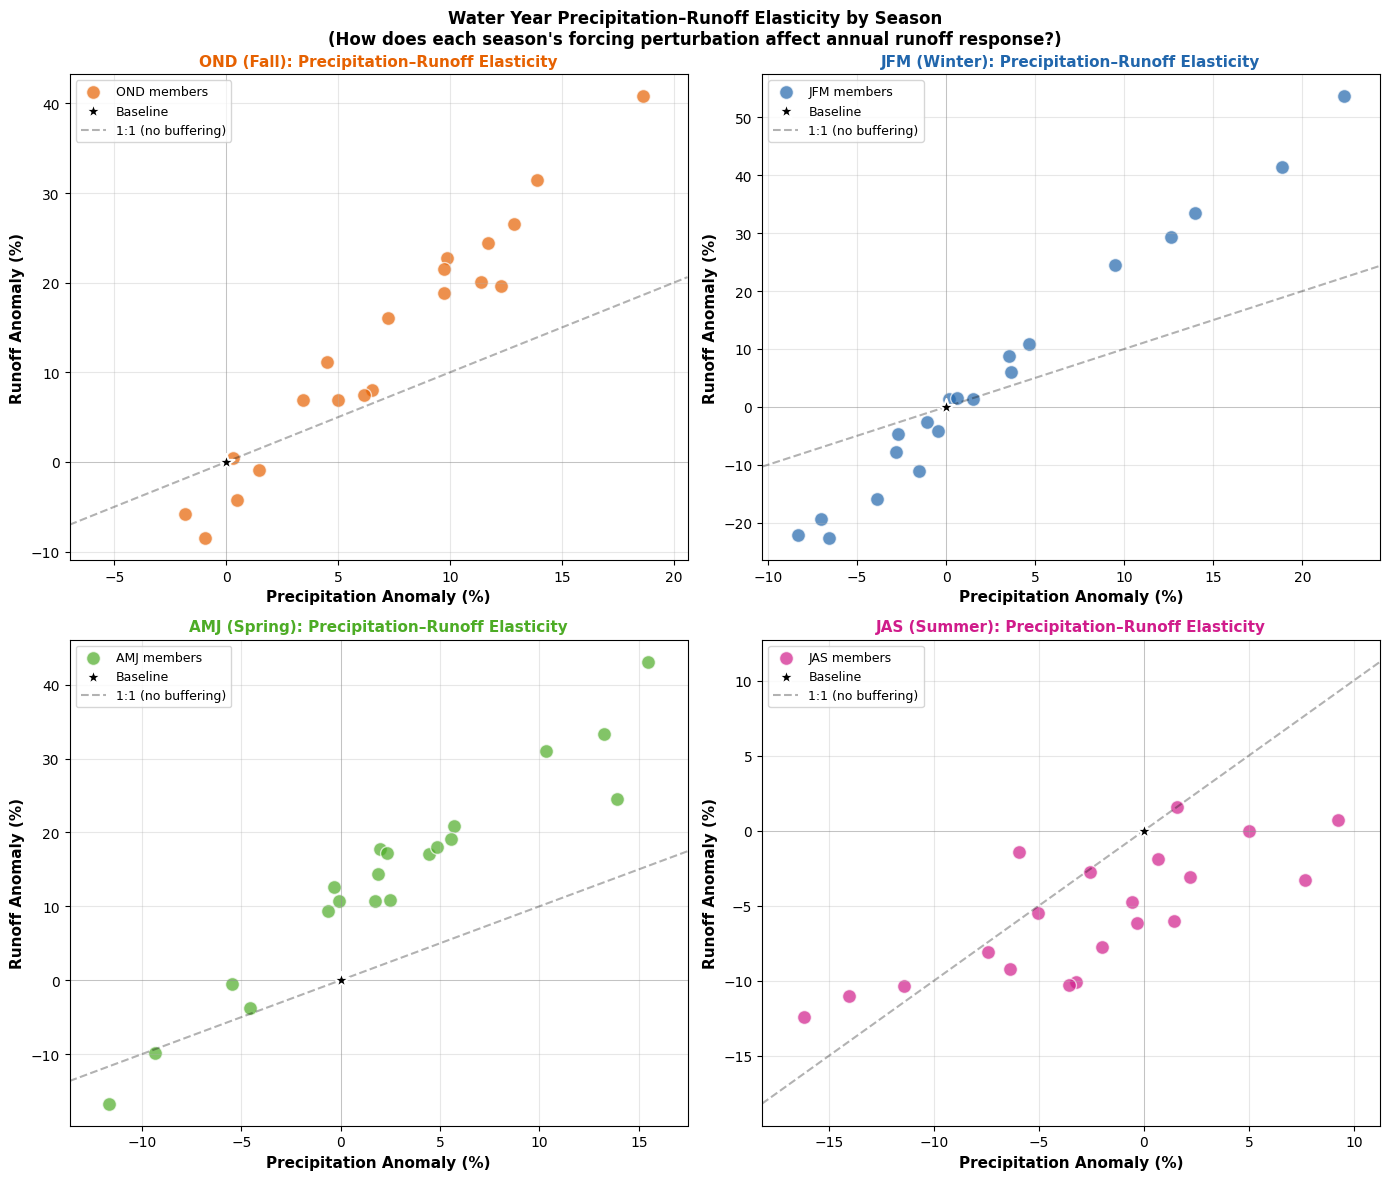

In [28]:
# Runoff Ratio Sensitivity: WY-level elasticity by season
# Shows how precipitation and runoff respond when each season is perturbed

if 'wy_df' not in locals():
    print("WY metrics not computed yet - run the helper cell above first")
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    
    for idx, season in enumerate(SEASONS):
        ax = axes[idx]
        season_data = wy_df[(wy_df['season'] == season) & (wy_df['season'] != 'baseline')]
        
        if season_data.empty:
            ax.set_title(f'{season} (no data)')
            continue
        
        # Plot each member as (P_anom_pct, Q_anom_pct)
        ax.scatter(season_data['P_anom_pct'], season_data['Q_anom_pct'],
                  color=SEASONS[season]['color'], alpha=0.7, s=100, 
                  edgecolors='white', linewidth=1, label=f'{season} members')
        
        # Plot baseline point at origin
        ax.scatter([0], [0], color='black', s=150, marker='*', 
                  edgecolors='white', linewidth=1.5, label='Baseline', zorder=5)
        
        # Add 1:1 line (equal response)
        lims = [min(season_data['P_anom_pct'].min(), -5) - 2, 
               max(season_data['P_anom_pct'].max(), 5) + 2]
        ax.plot(lims, lims, 'k--', alpha=0.3, linewidth=1.5, label='1:1 (no buffering)')
        
        # Add best-fit elasticity line
        # if len(season_data) > 1:
        #     z = np.polyfit(season_data['P_anom_pct'], season_data['Q_anom_pct'], 1)
        #     p = np.poly1d(z)
        #     p_range = np.array(lims)
        #     ax.plot(p_range, p(p_range), color=SEASONS[season]['color'], linewidth=2, 
        #            linestyle='-', alpha=0.7, label=f'Elasticity = {z[0]:.2f}')
        
        ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
        ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)
        ax.set_xlim(lims)
        ax.set_xlabel('Precipitation Anomaly (%)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Runoff Anomaly (%)', fontsize=11, fontweight='bold')
        ax.set_title(f"{season} ({SEASONS[season]['name']}): Precipitation–Runoff Elasticity", 
                    fontweight='bold', fontsize=11, color=SEASONS[season]['color'])
        ax.legend(loc='upper left', fontsize=9)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('Water Year Precipitation–Runoff Elasticity by Season\n(How does each season\'s forcing perturbation affect annual runoff response?)', 
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 9c. ET and Storage Change Sensitivity

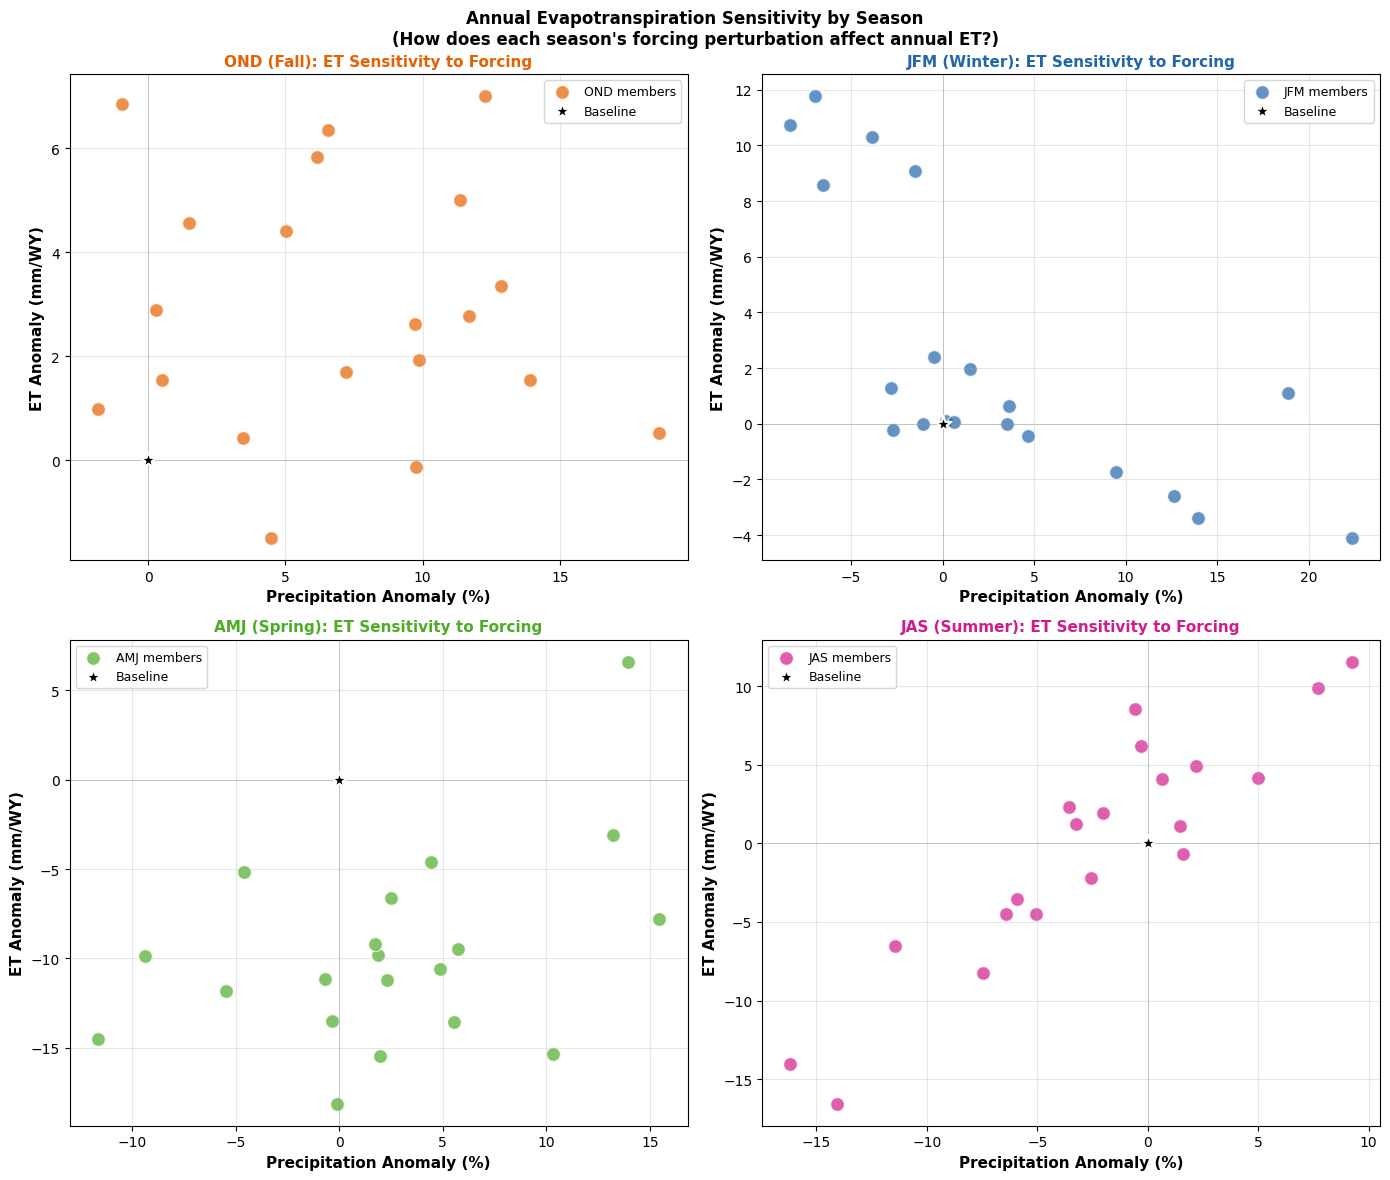

In [29]:
# ET Sensitivity: WY-level anomalies when each season is perturbed
# Shows ET responds when a single season's forcing is changed

if 'wy_df' not in locals():
    print("WY metrics not computed yet - run the helper cell above first")
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    
    for idx, season in enumerate(SEASONS):
        ax = axes[idx]
        season_data = wy_df[(wy_df['season'] == season) & (wy_df['season'] != 'baseline')]
        
        if season_data.empty:
            ax.set_title(f'{season} (no data)')
            continue
        
        # Plot ET anomaly vs P anomaly
        ax.scatter(season_data['P_anom_pct'], season_data['ET_anom_pct'],
                  color=SEASONS[season]['color'], alpha=0.7, s=100,
                  edgecolors='white', linewidth=1, label=f'{season} members')
        
        # Plot baseline at origin
        ax.scatter([0], [0], color='black', s=150, marker='*',
                  edgecolors='white', linewidth=1.5, label='Baseline', zorder=5)
        
        # Add best-fit line
        # if len(season_data) > 1:
        #     z = np.polyfit(season_data['P_anom_pct'], season_data['ET_anom_pct'], 1)
        #     p = np.poly1d(z)
        #     p_range = np.array([season_data['P_anom_pct'].min() - 1, season_data['P_anom_pct'].max() + 1])
        #     ax.plot(p_range, p(p_range), color=SEASONS[season]['color'], linewidth=2,
        #            linestyle='-', alpha=0.7, label=f'Sensitivity = {z[0]:.2f} mm/mm')
        
        ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
        ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)
        ax.set_xlabel('Precipitation Anomaly (%)', fontsize=11, fontweight='bold')
        ax.set_ylabel('ET Anomaly (mm/WY)', fontsize=11, fontweight='bold')
        ax.set_title(f"{season} ({SEASONS[season]['name']}): ET Sensitivity to Forcing", 
                    fontweight='bold', fontsize=11, color=SEASONS[season]['color'])
        ax.legend(loc='best', fontsize=9)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('Annual Evapotranspiration Sensitivity by Season\n(How does each season\'s forcing perturbation affect annual ET?)', 
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 10. Summary Statistics

In [45]:
summary_path = exp.cfg.ensemble_dir / 'sensitivity_summary.csv'
if summary_path.exists():
    summary = pd.read_csv(summary_path)
else:
    summary = exp.sensitivity_summary

if summary is not None:
    print("\nSensitivity Summary:")
    print("=" * 70)
    
    # Highlight the most sensitive season for each metric
    for metric in ['Q_std', 'ET_std', 'delta_S_std', 'RR_std']:
        if metric in summary.columns:
            max_idx = summary[metric].idxmax()
            max_season = summary.loc[max_idx, 'season']
            max_val = summary.loc[max_idx, metric]
            print(f"  Most sensitive to {metric:12s}: {max_season} ({max_val:.6f})")
    
    print(f"\nPrecip–Runoff Elasticity:")
    for _, row in summary.iterrows():
        elast = row.get('elasticity_Q_to_P', np.nan)
        interp = '(amplified)' if elast > 1 else '(buffered)' if elast < 1 else ''
        print(f"  {row['season']:3s} ({row['season_name']:6s}): {elast:.2f} {interp}")

    display(summary)


Sensitivity Summary:
  Most sensitive to Q_std       : AMJ (0.000000)
  Most sensitive to ET_std      : AMJ (0.000226)
  Most sensitive to delta_S_std : JFM (0.410390)
  Most sensitive to RR_std      : AMJ (0.000065)

Precip–Runoff Elasticity:
  OND (Fall  ): 0.11 (buffered)
  JFM (Winter): -14.50 (buffered)
  AMJ (Spring): -0.13 (buffered)
  JAS (Summer): 1.06 (amplified)


,season,season_name,n_members,P_std,P_range,ET_std,ET_range,Q_std,Q_range,RR_std,RR_range,delta_S_std,delta_S_range,mean_P_anomaly_pct,mean_ET_anomaly_pct,mean_Q_anomaly_pct,mean_RR_anomaly_pct,elasticity_Q_to_P
0,OND,Fall,20,0.000376,0.001378,0.000064,0.000244,7.050708e-09,2.717855e-08,5.106527e-06,0.000020,0.131720,0.447319,33.347508,28.444409,-13.936834,-33.204210,0.107445
1,JFM,Winter,20,0.000574,0.002067,0.000097,0.000437,6.871627e-10,3.073901e-09,3.586574e-07,0.000002,0.410390,1.045063,10.240917,89.640148,1560.681467,1522.770672,-14.496797
2,AMJ,Spring,20,0.000485,0.001825,0.000226,0.000697,7.819826e-08,3.464977e-07,6.526178e-05,0.000293,0.367587,1.565649,11.650468,44.882152,-89.872074,-88.671393,-0.134463
3,JAS,Summer,20,0.000446,0.001714,0.000193,0.000741,5.815485e-08,2.091597e-07,2.732554e-05,0.000107,0.230462,0.919684,-8.910192,33.840129,40.777116,58.631583,1.057899


---
## Quick Reference

### Analysis-First Path

For the completed East River WY2021 experiment, the shortest path is:

1. Run the setup and configuration cells
2. Run **Section 1a** to load `target_wy_2021_timestep.nc` and collect ensemble outputs
3. Optionally run **Section 6d** to inspect the discovered members
4. Start at **Step 6** for evaluation and plotting

### Output Naming Convention

| Item | Pattern | Example |
|------|---------|---------|
| Target baseline | `seasonal_ensemble/results/baseline/target_wy_{target}_timestep.nc` | `results/baseline/target_wy_2021_timestep.nc` |
| Ensemble results dir | `seasonal_ensemble/results/{season}/from_{donor}/` | `results/MAM/from_2005/` |
| Member output NC | `{domain}_{season}_from{donor}_timestep.nc` | `East_River_lumped_MAM_from2005_timestep.nc` |
| Member log | `seasonal_ensemble/logs/{season}_from{donor}.log` | `logs/MAM_from2005.log` |
| Ensemble forcing dir | `seasonal_ensemble/forcing/{season}/from_{donor}/` | `forcing/MAM/from_2005/` |

### Execution Modes

| Mode | When to Use | How |
|------|------------|-----|
| **Analysis only** | Results already exist on disk | Run Section 1a, then jump to Step 6 |
| **Parallel rebuild** | Recreate outputs interactively | Set `ANALYSIS_ONLY = False`, then run `exp.step5_run_ensembles(parallel=True)` |
| **Overnight script** | Rebuild and leave it running | Set `ANALYSIS_ONLY = False`, generate `run_ensemble.sh`, then launch it |
| **Sequential** | Debugging one member at a time | Set `ANALYSIS_ONLY = False`, then run `exp.step5_run_ensembles(parallel=False)` |

### Running Overnight with tmux

```bash
# 1. Create a tmux session
tmux new -s ensemble

# 2. Activate environment
conda activate CONFLUENCE-base

# 3. Run from the modeling directory
cd /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/modeling

# 4. Work from the notebook or generate the run script from Python
# 5. Detach: Ctrl+B then D
# 6. Reconnect: tmux attach -t ensemble
```

### Individual Steps

- `exp.check_data_coverage()` — Verify forcing + obs coverage
- `exp.step0_prepare_data()` — Download obs / create forcing (needs internet)
- `exp.step1_optimize()` — Find best parameters
- `exp.step2_long_term_run()` — Long-term baseline run
- `exp.step2b_create_warm_state()` — Extract final state into `warmState.nc`
- `exp.step3_target_year_baseline()` — Target water-year control run
- `exp.step4_build_ensembles()` — Create seasonal forcing member directories
- `exp.step5_run_ensembles()` — Launch ensemble members
- `exp.step5_generate_script()` — Generate bash script for nohup/tmux
- `exp.step5_collect_results()` — Scan for completed outputs on disk
- `exp.step6_evaluate()` — Compute water-balance metrics
- `exp.step7_visualize()` — Generate spaghetti plots and summary figures

In [31]:
ds_longterm = xr.open_dataset("/scratch/dlhogan/ess-project-data/domain_East_River_lumped/simulations/longterm_baseline/SUMMA/longterm_baseline_timestep.nc")
obs_ds = pd.read_csv("/scratch/dlhogan/ess-project-data/domain_East_River_lumped/observations/streamflow/preprocessed/East_River_lumped_streamflow_processed.csv", parse_dates=['datetime'], index_col=0).loc["2020-10-01":"2021-09-30"]
baseline = xr.open_dataset("/scratch/dlhogan/ess-project-data/domain_East_River_lumped/seasonal_ensemble/results/baseline/target_wy_2021_timestep.nc")

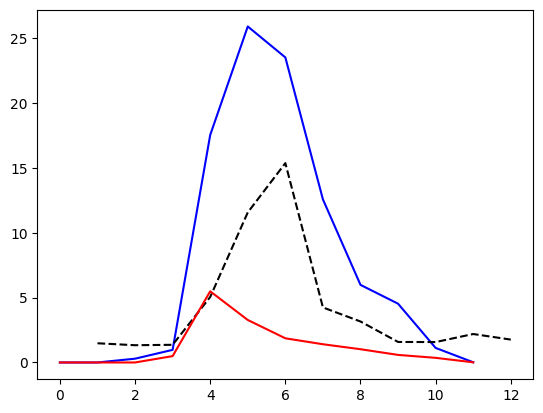

In [22]:
plt.plot(ds_longterm['scalarTotalRunoff'].groupby('time.month').mean(dim='time') * exp.cfg.basin_area_m2, label='Long-term Baseline', color='blue')
plt.plot(obs_ds.groupby(obs_ds.index.month).mean(), label='Observations', color='black', linestyle='--')
plt.plot(baseline['scalarTotalRunoff'].groupby('time.month').mean(dim='time') * exp.cfg.basin_area_m2, label='baseline', color='red')
